# Clustering: jerárquico y k-means

**Unidad 9 · Machine Learning · Notebook 4 de 6**

Primer notebook del bloque **no supervisado**. Desaparece la etiqueta.

## Lo que cambia cuando no hay etiqueta

Los tres notebooks anteriores tenían una respuesta correcta contra la cual medirse. Eso
permitía una definición limpia de éxito: error de predicción bajo sobre datos no vistos, y una
regla de decisión mecánica —el modelo con mejor validación cruzada gana.

Acá eso desaparece. Tenemos $\{x_1, \dots, x_n\}$ y buscamos estructura. **No hay contra qué
comparar**, y eso tiene tres consecuencias que atraviesan todo el notebook:

1. **Ningún agrupamiento es correcto o incorrecto.** Es más o menos útil e interpretable para
   la pregunta que se tiene entre manos. Dos métodos pueden dar particiones distintas y las dos
   pueden ser defendibles.
2. **Las métricas internas —silueta, codo— no miden verdad**, miden propiedades geométricas de
   la partición. Que la silueta se maximice en $k=2$ no significa que haya dos grupos en el
   mundo.
3. **El criterio sustantivo del investigador vuelve al centro.** En clustering, la teoría no es
   un adorno que se agrega al final: es lo que decide cuántos grupos hay y cómo se llaman.

Eso no significa que todo valga. Hay dos formas serias de validar un agrupamiento, y las vamos
a usar las dos: **validación externa** (comparar contra una clasificación construida
independientemente) y **estabilidad** (ver si la estructura sobrevive a cambios de método).

## Requisitos

In [1]:
# Requisitos de este notebook.
# Si te falta alguno, instalalo EN TU PROPIO ENTORNO desde una terminal
# (o descomentando la linea de abajo) y reinicia el kernel:
#
#     pip install numpy pandas matplotlib seaborn scikit-learn statsmodels
#
# %pip install numpy pandas matplotlib seaborn scikit-learn statsmodels

import importlib

_requeridos = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'sklearn', 'statsmodels']
_faltan = []
for _m in _requeridos:
    try:
        _mod = importlib.import_module(_m)
        print(f"  {_m:16s} {getattr(_mod, '__version__', 'sin version')}")
    except ImportError:
        _faltan.append(_m)
        print(f"  {_m:16s} FALTA")

if _faltan:
    print(f"\nFaltan {len(_faltan)} paquetes: {', '.join(_faltan)}.")
    print("Instalalos en tu entorno antes de seguir.")
else:
    print("\nTodo listo.")

  numpy            1.26.4
  pandas           2.2.2


  matplotlib       3.9.2


  seaborn          0.13.2


  sklearn          1.9.0
  statsmodels      0.14.2

Todo listo.


## Librerías

In [2]:
import os
import warnings

os.environ.setdefault("OMP_NUM_THREADS", "1")
warnings.filterwarnings("ignore", message=".*memory leak.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import cophenet, dendrogram, fcluster, linkage
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (adjusted_rand_score, calinski_harabasz_score,
                             silhouette_samples, silhouette_score)
from sklearn.preprocessing import StandardScaler
from statsmodels.multivariate.manova import MANOVA

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)

SEED = 42
rng = np.random.default_rng(SEED)
PALETA = ["#0073C2", "#EFC000", "#CD534C", "#868686", "#1E2749"]

## La pregunta y los datos

> **¿Cuántos tipos de régimen político hay, y quién está en cada uno?**

Es una de las preguntas fundacionales de la política comparada. Las respuestas clásicas
—democracia / autoritarismo, o la tripartición con regímenes híbridos— provienen de decisiones
teóricas y de clasificaciones construidas a mano por equipos de expertos, como Freedom House o
Polity.

El clustering ofrece otro camino: **dejar que los datos digan cuántos grupos hay**, sin
imponerle categorías. Y después comparar el resultado con las clasificaciones existentes, que
es la validación externa.

Volvemos a QOG, el mismo dataset de `9.1`, pero con otro conjunto de variables y otra pregunta.
En `9.1` usamos indicadores para **predecir corrupción**; acá usamos indicadores de **calidad y
tipo de régimen** para describir estructura. Hay solapamiento parcial —los índices de V-Dem
aparecen en los dos— y conviene decirlo: la diferencia no está en los datos sino en qué se les
pide.

In [3]:
qog = pd.read_stata("../../dataset/QOG/qog_bas_cs_jan26.dta", convert_categoricals=False)

VARIABLES = ["vdem_polyarchy", "vdem_libdem", "vdem_egaldem", "vdem_partipdem",
             "vdem_delibdem", "fh_pr", "fh_cl", "wbgi_pve", "ipu_l_sw"]

ETIQUETAS = {
    "vdem_polyarchy": "Democracia electoral",
    "vdem_libdem": "Democracia liberal",
    "vdem_egaldem": "Democracia igualitaria",
    "vdem_partipdem": "Democracia participativa",
    "vdem_delibdem": "Democracia deliberativa",
    "fh_pr": "Derechos políticos (FH, 1=mejor)",
    "fh_cl": "Libertades civiles (FH, 1=mejor)",
    "wbgi_pve": "Estabilidad política",
    "ipu_l_sw": "% de mujeres en el legislativo",
}

datos = (qog[["cname", "ht_region", "fh_status", "bmr_dem"] + VARIABLES]
         .dropna(subset=VARIABLES).reset_index(drop=True))

print(f"países con las 9 variables completas: {len(datos)} de {len(qog)}")
datos[VARIABLES].describe().T.round(2)

países con las 9 variables completas: 170 de 194


,count,mean,std,min,25%,50%,75%,max
vdem_polyarchy,170.0,0.50,0.26,0.02,0.27,0.52,0.75,0.92
vdem_libdem,170.0,0.39,0.27,0.01,0.14,0.37,0.65,0.89
vdem_egaldem,170.0,0.38,0.24,0.02,0.18,0.34,0.59,0.88
vdem_partipdem,170.0,0.33,0.20,0.01,0.15,0.32,0.49,0.80
vdem_delibdem,170.0,0.39,0.25,0.01,0.19,0.35,0.62,0.88
fh_pr,170.0,3.84,2.24,1.00,2.00,3.50,6.00,7.00
fh_cl,170.0,3.66,1.91,1.00,2.00,4.00,5.00,7.00
wbgi_pve,170.0,-0.17,0.90,-2.61,-0.71,-0.15,0.52,1.32
ipu_l_sw,170.0,25.94,12.54,0.00,16.95,25.90,35.28,61.30


### Una variable que quedó afuera, y por qué

El candidato natural para una tipología de regímenes era `bmr_demdur`, la **duración del
régimen** de Boix-Miller-Rosato. La descartamos, y el motivo es instructivo.

In [4]:
print("Los valores más altos de bmr_demdur entre países clasificados como NO libres:\n")
print(qog.loc[qog["fh_status"] == 3, ["cname", "bmr_demdur", "fh_status"]]
      .nlargest(6, "bmr_demdur").to_string(index=False))

Los valores más altos de bmr_demdur entre países clasificados como NO libres:

                     cname  bmr_demdur  fh_status
               Afghanistan       221.0        3.0
                     China       221.0        3.0
Iran (Islamic Republic of)       221.0        3.0
                      Oman       221.0        3.0
                     Haiti       201.0        3.0
                     Egypt        99.0        3.0


China, Irán y Afganistán tienen una "duración de régimen" de **221**. No son democracias de dos
siglos: la variable cuenta los años **desde el inicio de la serie (1800)** para los países que
nunca cambiaron de régimen, así que para las autocracias estables mide antigüedad del
autoritarismo y para las democracias mide antigüedad de la democracia. **Los valores no son
comparables entre sí.**

Al incluirla, el clustering formaba un grupo definido enteramente por ese artefacto de
codificación. La descartamos.

Esto no es un detalle: es el trabajo. **Antes de clusterizar hay que entender qué mide cada
variable**, porque el algoritmo no distingue entre una dimensión sustantiva y un artefacto de
codificación. Va a usar las dos con el mismo entusiasmo.

## Teoría: todo empieza con una distancia

Clusterizar es agrupar lo parecido. Entonces la primera decisión —antes de elegir método, antes
de elegir $k$— es **qué significa "parecido"**.

Para dos observaciones $x$ e $y$ con $p$ variables:

$$ \text{Euclídea:}\quad d(x,y) = \sqrt{\sum_{j=1}^{p}(x_j - y_j)^2} $$

$$ \text{Manhattan:}\quad d(x,y) = \sum_{j=1}^{p}|x_j - y_j| $$

$$ \text{Minkowski:}\quad d(x,y) = \left(\sum_{j=1}^{p}|x_j - y_j|^{m}\right)^{1/m} $$

La Minkowski generaliza las dos: con $m=2$ es la euclídea, con $m=1$ la Manhattan. Al crecer
$m$, la distancia queda cada vez más dominada por la variable en la que las dos observaciones
más difieren.

Una cuarta opción, distinta en naturaleza:

$$ \text{Correlación:}\quad d(x,y) = 1 - \rho(x, y) $$

Esta mide si los **perfiles tienen la misma forma**, sin importar el nivel. Dos países con
puntajes bajos en todo pero con el mismo patrón relativo quedan cerca. Para tipologías donde
importa el perfil y no la magnitud, es la elección correcta; para la nuestra, donde el nivel de
democracia **es** lo que interesa, no.

Usamos la **euclídea**, que es el estándar y la única compatible con el criterio de Ward que
vamos a usar después.

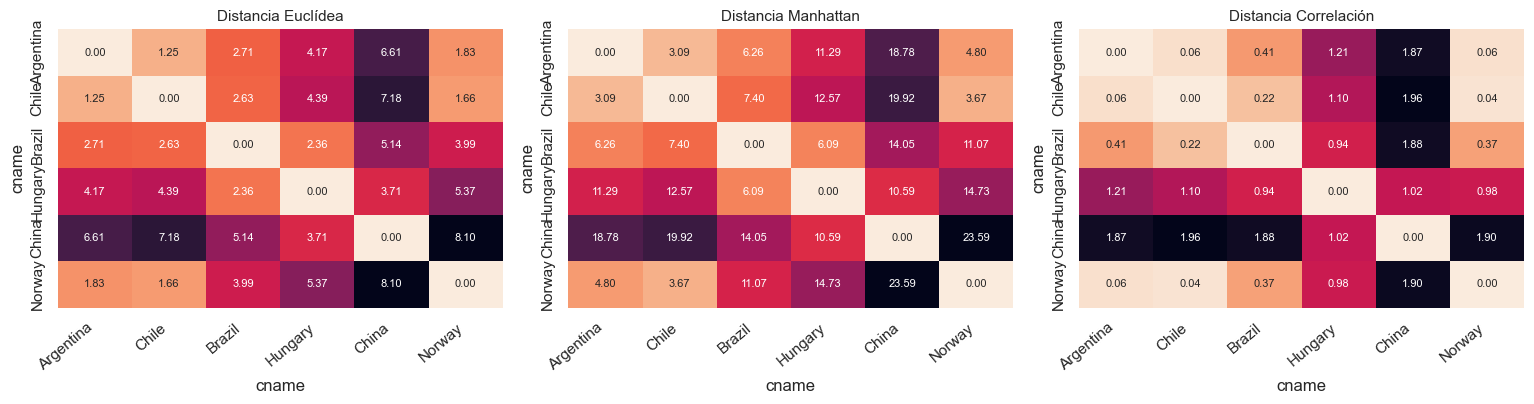

In [5]:
# Cómo cambia el vecino más cercano según la distancia elegida
ejemplo = datos.set_index("cname").loc[
    ["Argentina", "Chile", "Brazil", "Hungary", "China", "Norway"], VARIABLES]
ejemplo_esc = pd.DataFrame(StandardScaler().fit_transform(datos[VARIABLES]),
                           index=datos["cname"], columns=VARIABLES).loc[ejemplo.index]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))
for ax, metrica, titulo in zip(axes, ["euclidean", "cityblock", "correlation"],
                               ["Euclídea", "Manhattan", "Correlación"]):
    M = pd.DataFrame(squareform(pdist(ejemplo_esc, metric=metrica)),
                     index=ejemplo_esc.index, columns=ejemplo_esc.index)
    sns.heatmap(M, annot=True, fmt=".2f", cmap="rocket_r", cbar=False,
                annot_kws={"size": 8}, ax=ax)
    ax.set_title(f"Distancia {titulo}", fontsize=11)
    ax.tick_params(axis="x", rotation=40)
    for t in ax.get_xticklabels():
        t.set_ha("right")
plt.tight_layout()
plt.show()

Las tres matrices ordenan distinto. Con la euclídea y la Manhattan, Argentina está más cerca de
Chile que de China —lo esperable—. Con la **correlación** las distancias se comprimen y
reordenan, porque ya no mide cuánta democracia hay sino si el perfil entre las nueve
dimensiones tiene la misma forma.

**La elección de la distancia es una decisión sustantiva**, no un detalle técnico. Cambia qué
agrupamientos son posibles antes de que el algoritmo empiece a trabajar.

## Estandarizar no es opcional

Nuestras nueve variables están en escalas incompatibles: los índices de V-Dem van de 0 a 1, los
de Freedom House de 1 a 7, la estabilidad política de $-2.5$ a $2.5$, y el porcentaje de
mujeres en el legislativo de 0 a 60.

La distancia euclídea suma diferencias al cuadrado. Una variable con rango 60 aporta a esa suma
mucho más que una con rango 1, sin que eso tenga nada que ver con su importancia sustantiva.

In [6]:
X_crudo = datos[VARIABLES].values
X = StandardScaler().fit_transform(X_crudo)

comparacion = pd.DataFrame({
    "rango": datos[VARIABLES].max() - datos[VARIABLES].min(),
    "desvío": datos[VARIABLES].std(),
})
comparacion["aporte_sin_escalar_%"] = (
    (datos[VARIABLES].var() / datos[VARIABLES].var().sum()) * 100).round(2)
comparacion["aporte_escalado_%"] = round(100 / len(VARIABLES), 2)
comparacion.round(2)

,rango,desvío,aporte_sin_escalar_%,aporte_escalado_%
vdem_polyarchy,0.90,0.26,0.04,11.11
vdem_libdem,0.88,0.27,0.04,11.11
vdem_egaldem,0.86,0.24,0.03,11.11
vdem_partipdem,0.79,0.20,0.02,11.11
vdem_delibdem,0.87,0.25,0.04,11.11
fh_pr,6.00,2.24,3.00,11.11
fh_cl,6.00,1.91,2.18,11.11
wbgi_pve,3.93,0.90,0.48,11.11
ipu_l_sw,61.30,12.54,94.15,11.11


In [7]:
# Qué le pasa al agrupamiento si no se estandariza
lab_crudo = fcluster(linkage(X_crudo, method="ward"), 3, criterion="maxclust")
lab_esc = fcluster(linkage(X, method="ward"), 3, criterion="maxclust")

print(f"tamaños sin estandarizar: {np.bincount(lab_crudo)[1:]}")
print(f"tamaños estandarizando  : {np.bincount(lab_esc)[1:]}")
print(f"\ncoincidencia entre las dos particiones (ARI): "
      f"{adjusted_rand_score(lab_crudo, lab_esc):.3f}")
print(f"ARI de cada una contra la clasificación de Freedom House:")
print(f"  sin estandarizar: {adjusted_rand_score(datos['fh_status'], lab_crudo):.3f}")
print(f"  estandarizando  : {adjusted_rand_score(datos['fh_status'], lab_esc):.3f}")

tamaños sin estandarizar: [80 41 49]
tamaños estandarizando  : [61 43 66]

coincidencia entre las dos particiones (ARI): 0.075
ARI de cada una contra la clasificación de Freedom House:
  sin estandarizar: 0.047
  estandarizando  : 0.613


Sin estandarizar, el **94% de la varianza total** la aporta el porcentaje de mujeres en el
legislativo, simplemente porque está medido en una escala más ancha. El agrupamiento resultante
es esencialmente una partición por esa única variable, y su correspondencia con Freedom House se
desploma: el ARI cae de **0.61 a 0.05**, o sea a la coincidencia esperable por azar. Las dos
particiones ni siquiera se parecen entre sí (ARI de 0.08).

De acá en adelante, todo sobre datos estandarizados.

## Clustering jerárquico aglomerativo

Hay dos estrategias jerárquicas:

- **Aglomerativa** (*bottom-up*): cada observación arranca sola y se van fusionando los pares
  más cercanos hasta que queda un único grupo. Es la que se usa casi siempre.
- **Divisiva** (*top-down*): todo arranca en un solo grupo y se va partiendo. Más costosa
  computacionalmente y menos frecuente.

El algoritmo aglomerativo, en cuatro pasos:

1. Cada observación es un grupo. Calcular la matriz de distancias entre todos los pares.
2. Fusionar los dos grupos más cercanos.
3. Recalcular las distancias entre el grupo nuevo y todos los demás.
4. Repetir hasta que quede un grupo.

El resultado no es una partición sino un **árbol de particiones anidadas**: el dendrograma. Esa
es su gran ventaja sobre k-means — **no hay que decidir $k$ de antemano**, se decide después
mirando el árbol.

El paso 3 esconde toda la sustancia: cuando dos observaciones se fusionan en un grupo, ¿a qué
distancia queda ese grupo de los demás? La respuesta es el **criterio de enlace**.

### Los criterios de enlace

**Enlace simple** (*single*). La distancia entre dos grupos es la distancia **más corta** entre
un punto de uno y un punto del otro.

<figure style="text-align:center; margin:0.8em 0;">
  <img src="https://www.saedsayad.com/images/Clustering_single.png" width="300">
</figure>

Tiende a producir grupos alargados y encadenados: basta una secuencia de puntos intermedios
para que dos grupos muy distintos se unan. Ese efecto se llama *chaining* y en la práctica suele
ser un problema.

**Enlace completo** (*complete*). La distancia entre dos grupos es la **más larga** entre un
punto de uno y un punto del otro.

<figure style="text-align:center; margin:0.8em 0;">
  <img src="https://www.saedsayad.com/images/Clustering_complete.png" width="300">
</figure>

Produce grupos compactos y de diámetro parecido. Es sensible a valores atípicos, porque un solo
punto lejano define la distancia de todo su grupo.

**Enlace promedio** (*average*, o UPGMA). La distancia entre dos grupos es el **promedio** de
todas las distancias entre pares de puntos de uno y del otro.

<figure style="text-align:center; margin:0.8em 0;">
  <img src="https://www.saedsayad.com/images/Clustering_average.png" width="300">
</figure>

Un compromiso entre los dos anteriores.

**Centroide** (*centroid*, UPGMC). La distancia entre los promedios de cada grupo.

**Ward.** No usa una distancia entre grupos sino un criterio distinto: fusiona el par cuya
unión produce **el menor aumento de la varianza intra-grupo total**. Es el único que optimiza
explícitamente lo mismo que k-means, y por eso los dos métodos suelen coincidir bastante. Tiende
a producir grupos de tamaño parecido, lo que es una ventaja cuando se busca una tipología y una
desventaja cuando los grupos reales son de tamaños muy distintos.

> Las descripciones de arriba corresponden a los métodos que `scipy.cluster.hierarchy` expone
> como `single`, `complete`, `average`, `weighted`, `centroid`, `median` y `ward`. El argumento
> `metric` acepta además de la euclídea una larga lista de distancias —Manhattan, Minkowski,
> Chebyshev, coseno, correlación, Jaccard, Mahalanobis, Hamming— pero **`ward` y `centroid`
> solo tienen sentido con la euclídea**, porque están definidos a partir de promedios.

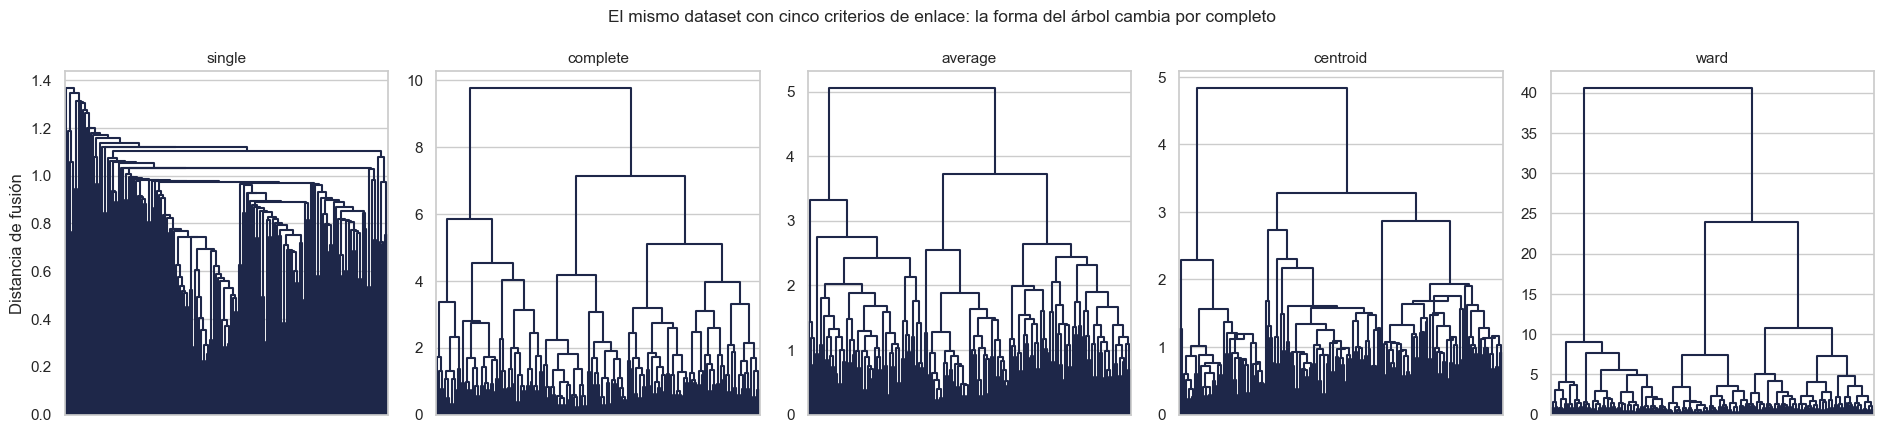

In [8]:
# Los cinco criterios sobre los mismos datos
METODOS = ["single", "complete", "average", "centroid", "ward"]
enlaces = {m: linkage(X, method=m, metric="euclidean") for m in METODOS}

fig, axes = plt.subplots(1, 5, figsize=(19, 4.4))
for ax, m in zip(axes, METODOS):
    dendrogram(enlaces[m], no_labels=True, ax=ax, color_threshold=0,
               above_threshold_color=PALETA[4])
    ax.set_title(m, fontsize=11)
    ax.set_xlabel("")
axes[0].set_ylabel("Distancia de fusión")
fig.suptitle("El mismo dataset con cinco criterios de enlace: la forma del árbol cambia por completo",
             fontsize=12.5)
plt.tight_layout()
plt.show()

El contraste es fuerte. `single` produce el patrón de encadenamiento clásico —una sucesión de
fusiones a alturas casi iguales, con una rama larga que se va comiendo puntos de a uno— y es
inútil para definir grupos. `ward` produce un árbol con ramas claramente separadas y grupos
comparables.

### Elegir el criterio: el coeficiente cofenético

Una forma cuantitativa de elegir. La **distancia cofenética** entre dos observaciones es la
altura del dendrograma a la que se fusionan por primera vez. El coeficiente cofenético es la
correlación entre esas alturas y las distancias originales: mide **cuán fielmente el árbol
representa la matriz de distancias**.

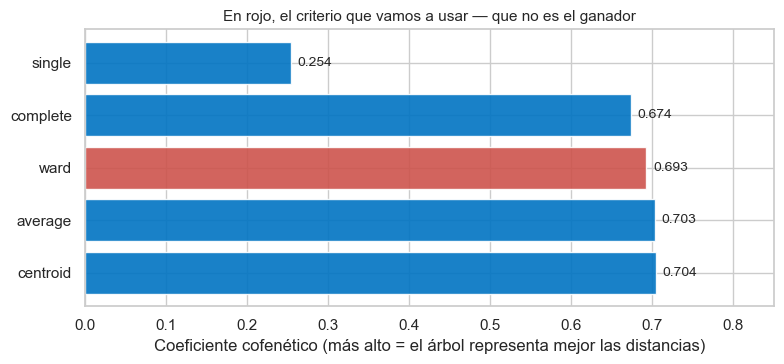

,coef. cofenético
centroid,0.704
average,0.703
ward,0.693
complete,0.674
single,0.254


In [9]:
D = pdist(X, metric="euclidean")
cofeneticos = pd.Series({m: cophenet(enlaces[m], D)[0] for m in METODOS},
                        name="coef. cofenético").sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 3.8))
colores = [PALETA[0] if m != "ward" else PALETA[2] for m in cofeneticos.index]
ax.barh(cofeneticos.index, cofeneticos.values, color=colores, alpha=0.9)
for i, v in enumerate(cofeneticos.values):
    ax.text(v + 0.008, i, f"{v:.3f}", va="center", fontsize=10)
ax.set_xlim(0, 0.85)
ax.set_xlabel("Coeficiente cofenético (más alto = el árbol representa mejor las distancias)")
ax.set_title("En rojo, el criterio que vamos a usar — que no es el ganador", fontsize=11)
plt.tight_layout()
plt.show()

cofeneticos.round(3).to_frame()

### Cuando la métrica y el criterio sustantivo no coinciden

`average` y `centroid` ganan (alrededor de 0.70) y `ward` queda tercero (0.69). Y sin embargo
vamos a usar **Ward**. Vale explicitar por qué, porque es el tipo de decisión que define un
análisis de clustering:

1. La diferencia es **chica** —una centésima— y el coeficiente cofenético no tiene una
   distribución de referencia que permita decir si es significativa.
2. `average` y `centroid` producen acá árboles **muy desbalanceados**: fusionan casi todo en una
   rama grande y dejan grupos de dos o tres países. Para una tipología de regímenes eso no
   sirve: no queremos descubrir que hay un grupo de 165 países y tres de dos.
3. Ward optimiza la varianza intra-grupo, que es **exactamente el criterio con el que después
   vamos a interpretar los grupos** (medias por cluster). Hay coherencia entre cómo se construye
   y cómo se lee.

Fidelidad a la matriz de distancias e interpretabilidad son objetivos distintos, y acá tiran
para lados distintos. Elegimos interpretabilidad y lo dejamos escrito.

In [10]:
# El tamaño de los grupos según el criterio, para k = 3
tamaños = pd.DataFrame({
    m: pd.Series(np.bincount(fcluster(enlaces[m], 3, criterion="maxclust"))[1:])
    for m in METODOS
}).T
tamaños.columns = [f"grupo {i+1}" for i in tamaños.columns]
tamaños.fillna(0).astype(int)

,grupo 1,grupo 2,grupo 3
single,4,165,1
complete,56,44,70
average,61,45,64
centroid,45,61,64
ward,61,43,66


## El dendrograma de 170 países

Con los nombres visibles, el dendrograma es un objeto que se puede leer país por país. Es la
principal razón para usar clustering jerárquico en política comparada: **muestra la estructura
de anidamiento**, no solo la partición final.

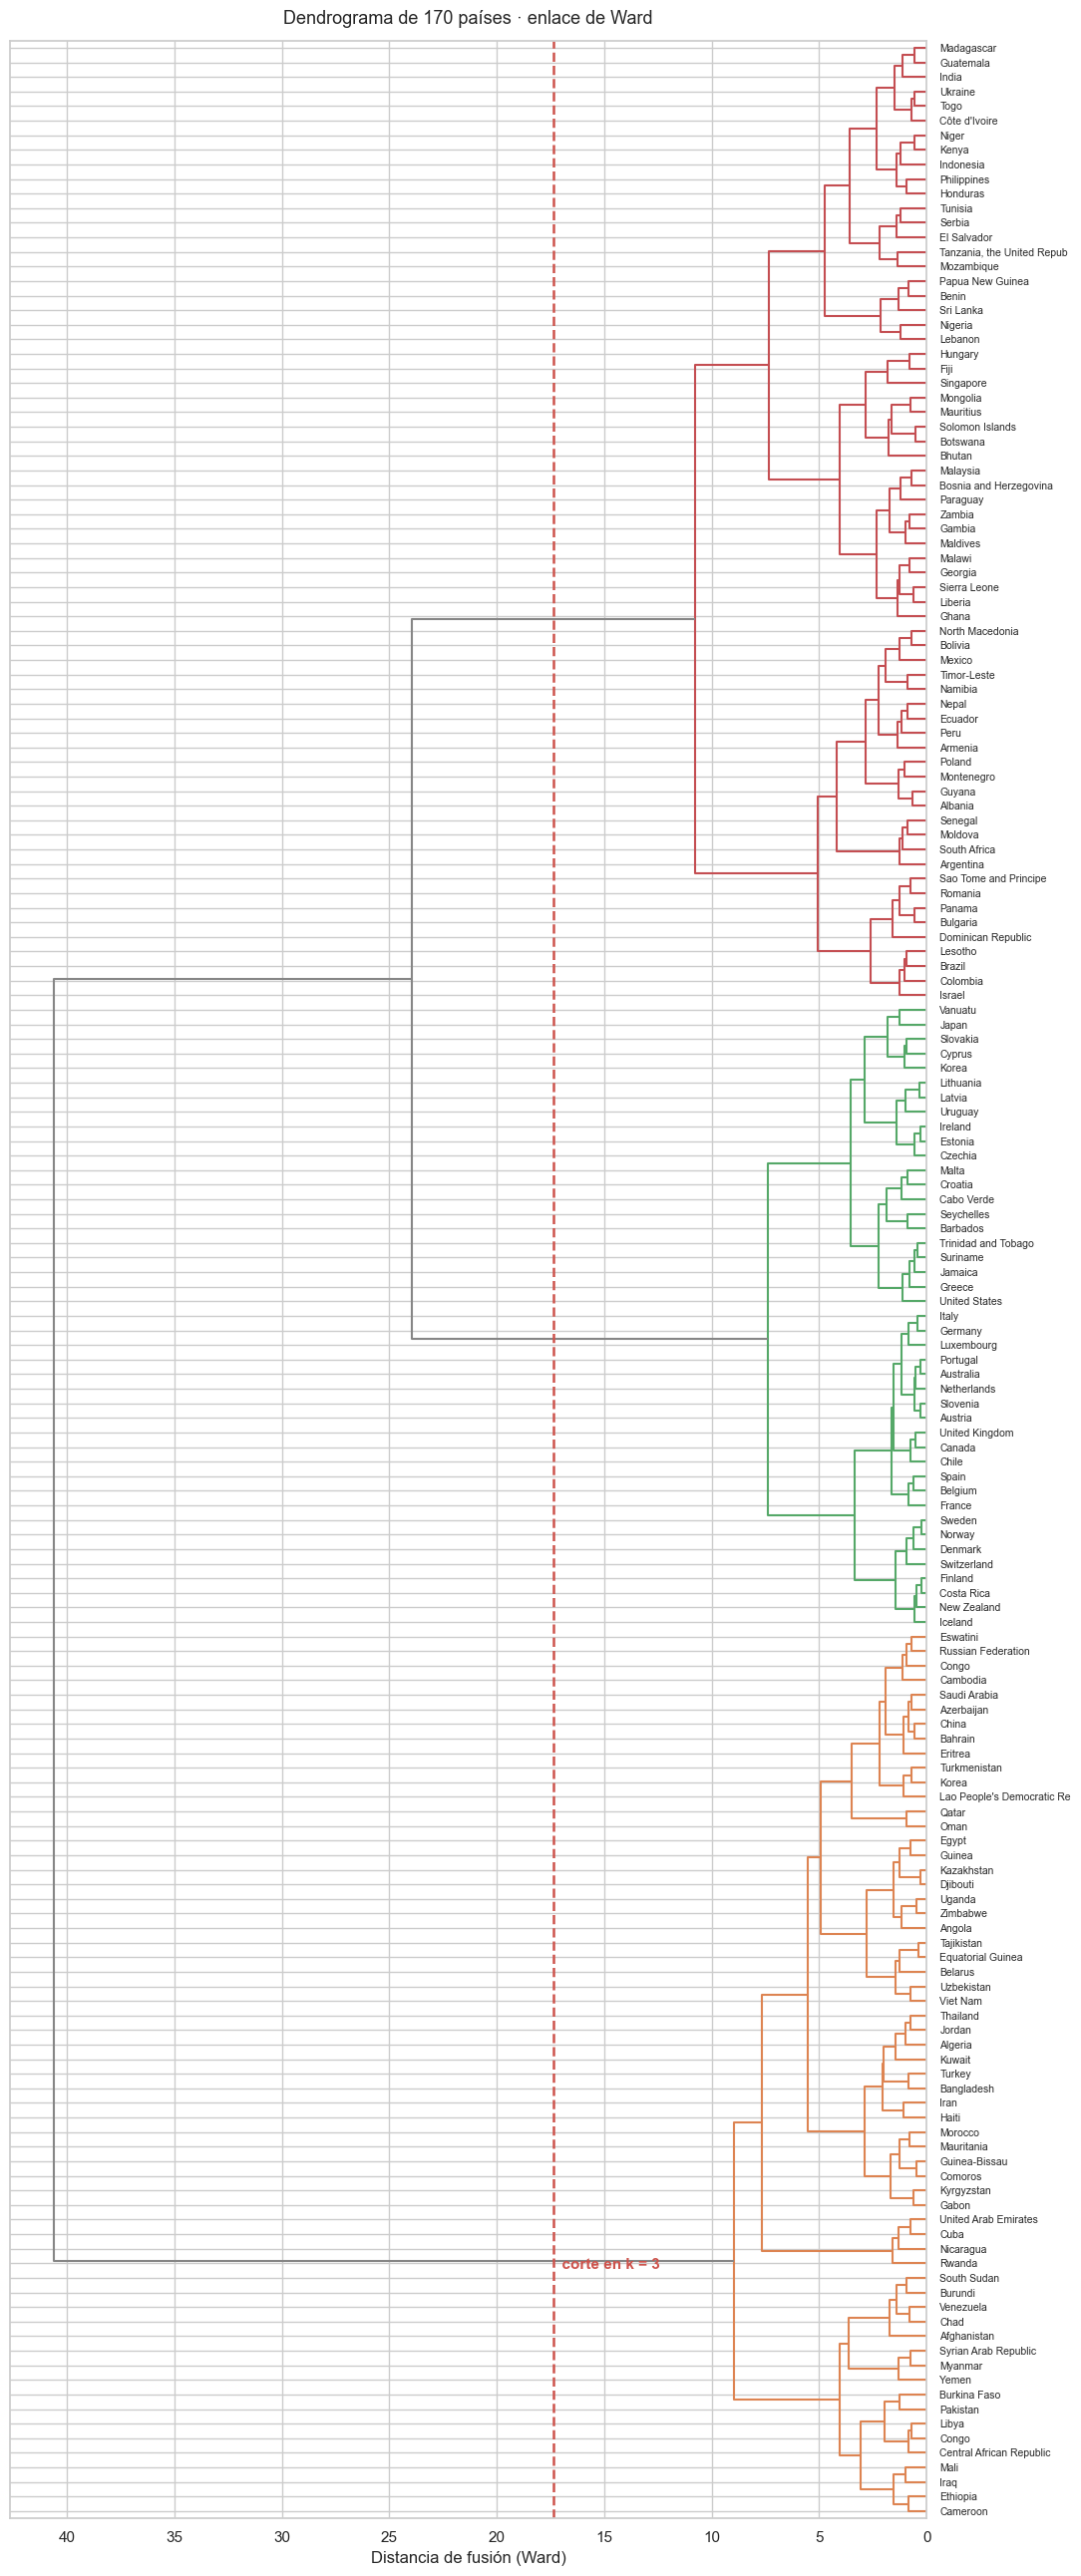

In [11]:
Z = enlaces["ward"]
nombres_cortos = (datos["cname"]
                  .str.replace(r"\s*\(.*\)", "", regex=True)
                  .str.replace("United Kingdom of Great Britain and Northern Ireland",
                               "United Kingdom", regex=False)
                  .str.replace("United States of America", "United States", regex=False)
                  .str.slice(0, 26).tolist())

K = 3
umbral = (Z[-K, 2] + Z[-(K - 1), 2]) / 2

fig, ax = plt.subplots(figsize=(11, 26))
dend = dendrogram(Z, labels=nombres_cortos, orientation="left", ax=ax,
                  color_threshold=umbral, leaf_font_size=7.5,
                  above_threshold_color=PALETA[3])
ax.axvline(umbral, color=PALETA[2], ls="--", lw=1.8)
ax.text(umbral, len(nombres_cortos) * 1.005, f"  corte en k = {K}",
        color=PALETA[2], fontsize=11, fontweight="bold")
ax.set_xlabel("Distancia de fusión (Ward)")
ax.set_title(f"Dendrograma de {len(datos)} países · enlace de Ward", fontsize=13, pad=12)
plt.tight_layout()
plt.show()

El árbol se lee de derecha a izquierda: cuanto más a la izquierda se fusionan dos países, más
distintos son. Las fusiones muy tempranas —a la derecha— son pares casi idénticos en las nueve
dimensiones.

Y ya se ve la estructura sin necesidad de ninguna métrica: hay **tres ramas grandes** que se
separan a alturas altas, y dentro de cada una, subestructura.

## ¿Cuántos grupos?

La pregunta central y la que no tiene respuesta puramente técnica. Cuatro herramientas, y
ninguna decide sola.

In [12]:
ks = range(2, 11)
metricas_k = []

for k in ks:
    lab_j = fcluster(Z, k, criterion="maxclust")
    km = KMeans(n_clusters=k, n_init=25, random_state=SEED).fit(X)
    metricas_k.append({
        "k": k,
        "inercia_kmeans": km.inertia_,
        "silueta_jerarquico": silhouette_score(X, lab_j),
        "silueta_kmeans": silhouette_score(X, km.labels_),
        "calinski_harabasz": calinski_harabasz_score(X, lab_j),
        "ARI_vs_FreedomHouse": adjusted_rand_score(datos["fh_status"], lab_j),
        "grupo_mas_chico": np.bincount(lab_j)[1:].min(),
    })

tabla_k = pd.DataFrame(metricas_k)
tabla_k.round(3)

,k,inercia_kmeans,silueta_jerarquico,silueta_kmeans,calinski_harabasz,ARI_vs_FreedomHouse,grupo_mas_chico
0,2,599.915,0.434,0.479,196.637,0.511,61
1,3,402.635,0.388,0.398,222.315,0.613,43
2,4,350.162,0.315,0.304,180.150,0.610,26
3,5,309.372,0.270,0.276,156.510,0.511,17
4,6,278.639,0.280,0.278,140.301,0.487,4
5,7,250.858,0.250,0.255,131.030,0.390,4
6,8,224.126,0.243,0.255,126.922,0.340,4
7,9,209.898,0.226,0.251,119.477,0.315,4
8,10,195.196,0.212,0.257,113.168,0.312,4


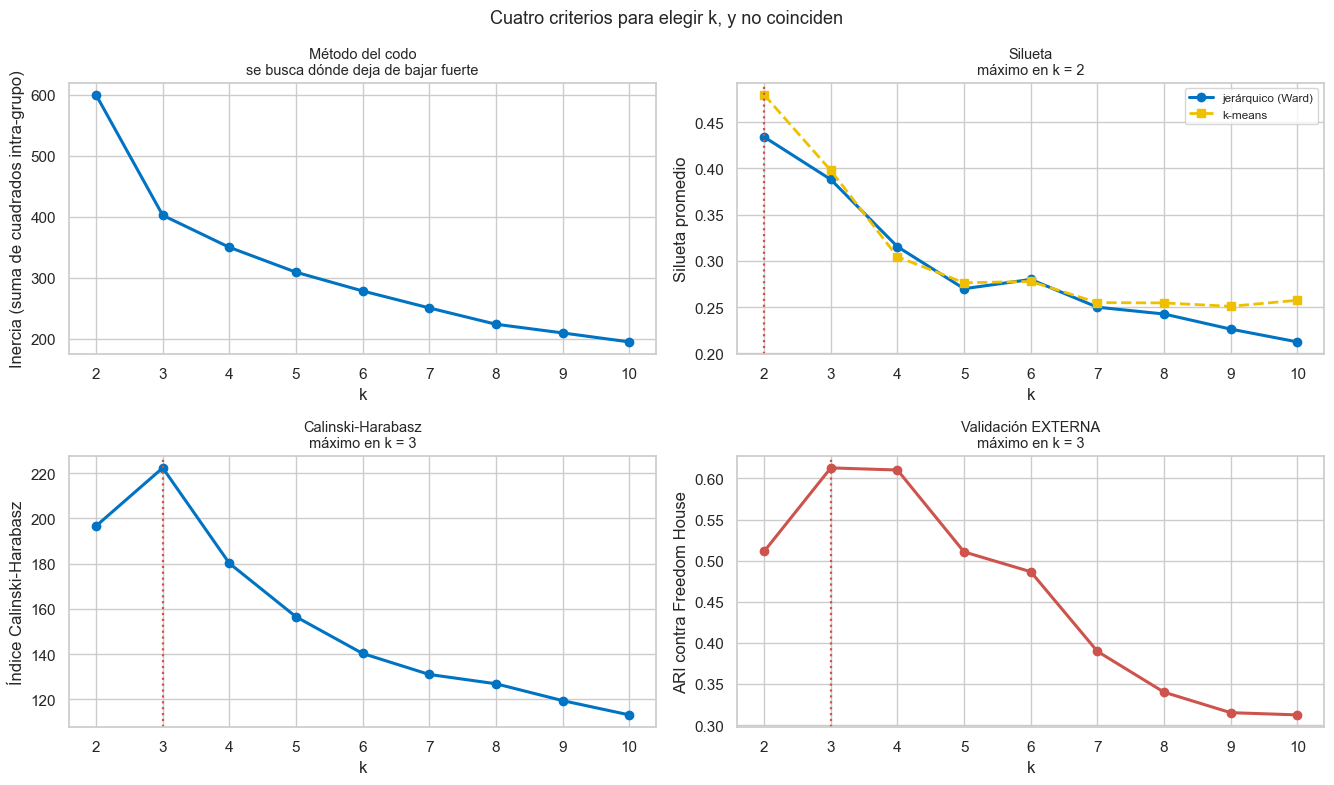

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 8))

ax = axes[0, 0]
ax.plot(tabla_k["k"], tabla_k["inercia_kmeans"], "o-", lw=2.2, color=PALETA[0])
ax.set_xlabel("k"); ax.set_ylabel("Inercia (suma de cuadrados intra-grupo)")
ax.set_title("Método del codo\nse busca dónde deja de bajar fuerte", fontsize=10.5)

ax = axes[0, 1]
ax.plot(tabla_k["k"], tabla_k["silueta_jerarquico"], "o-", lw=2.2, color=PALETA[0],
        label="jerárquico (Ward)")
ax.plot(tabla_k["k"], tabla_k["silueta_kmeans"], "s--", lw=2, color=PALETA[1],
        label="k-means")
ax.axvline(int(tabla_k.loc[tabla_k["silueta_jerarquico"].idxmax(), "k"]),
           color=PALETA[2], ls=":", lw=1.6)
ax.set_xlabel("k"); ax.set_ylabel("Silueta promedio")
ax.set_title("Silueta\nmáximo en k = 2", fontsize=10.5)
ax.legend(fontsize=8.5)

ax = axes[1, 0]
ax.plot(tabla_k["k"], tabla_k["calinski_harabasz"], "o-", lw=2.2, color=PALETA[0])
k_ch = int(tabla_k.loc[tabla_k["calinski_harabasz"].idxmax(), "k"])
ax.axvline(k_ch, color=PALETA[2], ls=":", lw=1.6)
ax.set_xlabel("k"); ax.set_ylabel("Índice Calinski-Harabasz")
ax.set_title(f"Calinski-Harabasz\nmáximo en k = {k_ch}", fontsize=10.5)

ax = axes[1, 1]
ax.plot(tabla_k["k"], tabla_k["ARI_vs_FreedomHouse"], "o-", lw=2.2, color=PALETA[2])
k_ari = int(tabla_k.loc[tabla_k["ARI_vs_FreedomHouse"].idxmax(), "k"])
ax.axvline(k_ari, color=PALETA[2], ls=":", lw=1.6)
ax.set_xlabel("k"); ax.set_ylabel("ARI contra Freedom House")
ax.set_title(f"Validación EXTERNA\nmáximo en k = {k_ari}", fontsize=10.5)

fig.suptitle("Cuatro criterios para elegir k, y no coinciden", fontsize=13)
plt.tight_layout()
plt.show()

### La decisión

Los cuatro criterios dicen cosas distintas, y eso es lo normal:

- **El codo** no tiene un quiebre nítido. Es la situación habitual: el método del codo suele ser
  el menos concluyente de los cuatro.
- **La silueta** se maximiza en $k = 2$, tanto para el jerárquico como para k-means. Es un
  resultado geométricamente correcto y sustantivamente pobre: dice que la separación más limpia
  es democracias contra el resto.
- **Calinski-Harabasz** se maximiza en $k = 3$.
- **La validación externa** —correspondencia con Freedom House— también se maximiza en
  $k = 3$, con un ARI de **0.61**.

Elegimos **$k = 3$**, y el argumento es la conjunción de dos cosas: dos de los cuatro criterios
lo señalan, y coincide con la tripartición que la literatura de política comparada usa desde los
años noventa —democracias, regímenes híbridos, autocracias—.

Que la silueta prefiera $k=2$ no invalida nada: la silueta mide compacidad geométrica, no
utilidad analítica. Si el objetivo fuera separar el mundo en dos bloques, $k=2$ sería mejor.
Como el objetivo es una tipología con capacidad de discriminar entre casos intermedios, $k=3$ lo
supera.

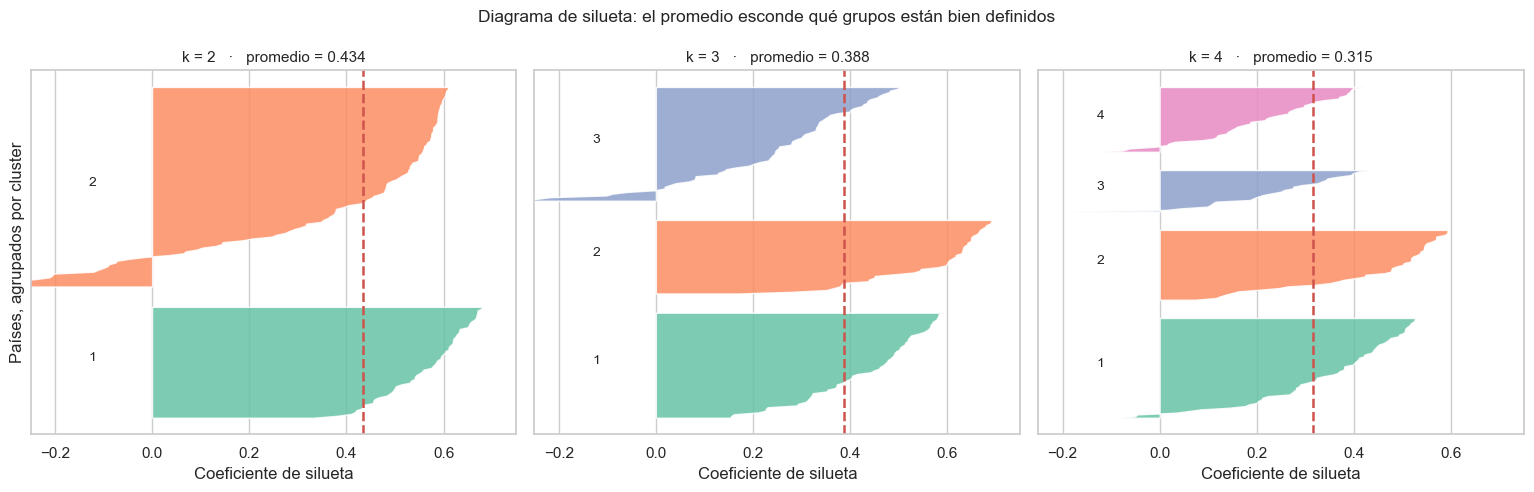

In [14]:
# El diagrama de silueta: qué esconde el promedio
fig, axes = plt.subplots(1, 3, figsize=(15.5, 5))

for ax, k in zip(axes, [2, 3, 4]):
    etiquetas = fcluster(Z, k, criterion="maxclust")
    sil_vals = silhouette_samples(X, etiquetas)
    promedio = sil_vals.mean()
    y_inf = 10
    for i in range(1, k + 1):
        vals = np.sort(sil_vals[etiquetas == i])
        y_sup = y_inf + len(vals)
        ax.fill_betweenx(np.arange(y_inf, y_sup), 0, vals,
                         facecolor=sns.color_palette("Set2")[i - 1], alpha=0.85)
        ax.text(-0.13, y_inf + 0.5 * len(vals), str(i), fontsize=10)
        y_inf = y_sup + 10
    ax.axvline(promedio, color=PALETA[2], ls="--", lw=1.8)
    ax.set_xlim(-0.25, 0.75)
    ax.set_yticks([])
    ax.set_xlabel("Coeficiente de silueta")
    ax.set_title(f"k = {k}   ·   promedio = {promedio:.3f}", fontsize=11)
axes[0].set_ylabel("Países, agrupados por cluster")
fig.suptitle("Diagrama de silueta: el promedio esconde qué grupos están bien definidos",
             fontsize=12.5)
plt.tight_layout()
plt.show()

Esta figura dice mucho más que el promedio. Se ve que los grupos **no están igual de bien
definidos**: alguno tiene siluetas altas y homogéneas —grupo compacto y bien separado— y otro
tiene una cola de valores cercanos a cero o negativos, o sea países que están casi tan cerca del
grupo vecino como del propio.

Los valores negativos son informativos: son casos que el algoritmo asignó a un grupo pero que
geométricamente pertenecerían a otro. **En una tipología de regímenes, esos son los casos
interesantes** — los que están en transición o no encajan en ninguna categoría. Volveremos sobre
esto con Argentina.

## k-means

El clustering jerárquico construye un árbol. k-means hace algo distinto: fija $k$ de antemano y
busca la partición que minimiza la suma de distancias al cuadrado de cada punto a su centroide:

$$ \min_{C_1,\dots,C_k} \sum_{i=1}^{k} \sum_{x \in C_i} \|x - \mu_i\|^2 $$

donde $\mu_i$ es la media del grupo $i$. Esa cantidad es la **inercia**, la misma que graficamos
en el codo.

El problema es NP-difícil, así que se resuelve con un algoritmo iterativo —el **algoritmo de
Lloyd**— que garantiza converger a un mínimo local:

1. Elegir $k$ centroides iniciales.
2. **Asignar** cada punto al centroide más cercano.
3. **Recalcular** cada centroide como la media de los puntos asignados.
4. Repetir 2 y 3 hasta que las asignaciones no cambien.

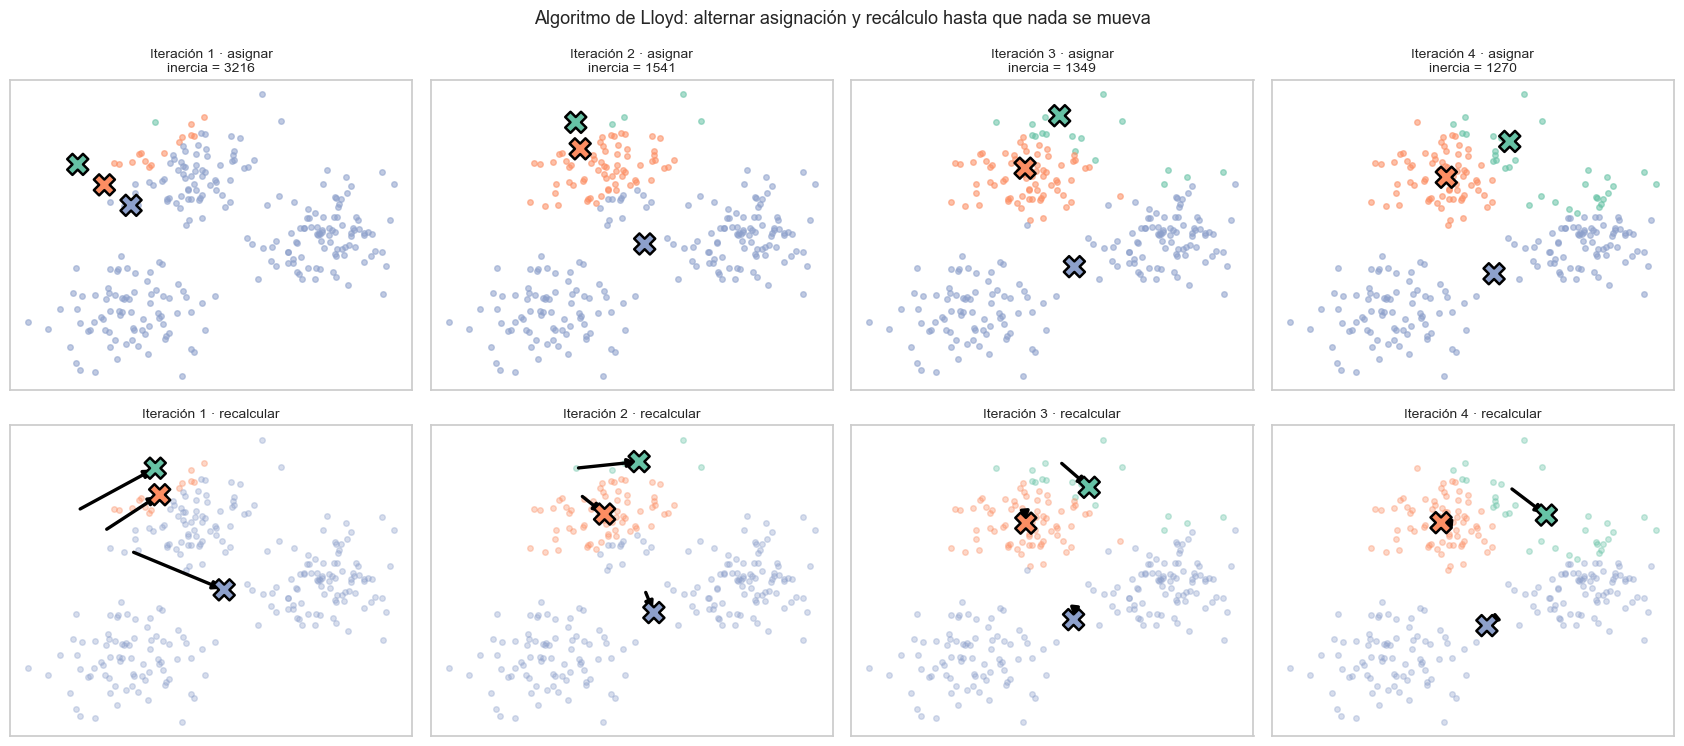

In [15]:
# El algoritmo de Lloyd, paso a paso
centros_v = np.array([[-2.0, -1.6], [2.4, 0.4], [-0.6, 2.4]])
g = rng.integers(0, 3, 260)
Xd = centros_v[g] + rng.normal(scale=0.78, size=(260, 2))

# inicialización deliberadamente mala, para que se vea el movimiento
centroides = np.array([[-3.2, 2.6], [-2.6, 2.0], [-2.0, 1.4]])

fig, axes = plt.subplots(2, 4, figsize=(17, 7.6))
for it in range(4):
    dist = np.linalg.norm(Xd[:, None, :] - centroides[None, :, :], axis=2)
    asignacion = dist.argmin(axis=1)

    ax = axes[0, it]
    for c in range(3):
        m = asignacion == c
        ax.scatter(Xd[m, 0], Xd[m, 1], s=16, alpha=0.55,
                   color=sns.color_palette("Set2")[c])
    ax.scatter(centroides[:, 0], centroides[:, 1], marker="X", s=230,
               c=[sns.color_palette("Set2")[i] for i in range(3)],
               edgecolor="black", linewidth=1.8, zorder=5)
    inercia = ((Xd - centroides[asignacion]) ** 2).sum()
    ax.set_title(f"Iteración {it + 1} · asignar\ninercia = {inercia:.0f}", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

    nuevos = np.array([Xd[asignacion == c].mean(axis=0) if (asignacion == c).any()
                       else centroides[c] for c in range(3)])
    ax = axes[1, it]
    for c in range(3):
        m = asignacion == c
        ax.scatter(Xd[m, 0], Xd[m, 1], s=16, alpha=0.35,
                   color=sns.color_palette("Set2")[c])
    for c in range(3):
        ax.annotate("", xy=nuevos[c], xytext=centroides[c],
                    arrowprops=dict(arrowstyle="-|>", lw=2.4, color="black"))
    ax.scatter(nuevos[:, 0], nuevos[:, 1], marker="X", s=230,
               c=[sns.color_palette("Set2")[i] for i in range(3)],
               edgecolor="black", linewidth=1.8, zorder=5)
    ax.set_title(f"Iteración {it + 1} · recalcular", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    centroides = nuevos

fig.suptitle("Algoritmo de Lloyd: alternar asignación y recálculo hasta que nada se mueva",
             fontsize=13)
plt.tight_layout()
plt.show()

### La inicialización importa

Como el algoritmo converge a un mínimo **local**, el resultado depende de dónde arranca. Dos
defensas, las dos activadas por defecto en scikit-learn:

- **`k-means++`**: elige los centroides iniciales de forma dispersa, con probabilidad
  proporcional a la distancia al centroide más cercano ya elegido. Reduce muchísimo la chance de
  una inicialización mala.
- **`n_init`**: corre el algoritmo varias veces con inicializaciones distintas y se queda con la
  de menor inercia. **Conviene fijarlo explícitamente** en lugar de confiar en el valor por
  defecto.

In [16]:
# Cuánto varía el resultado según la inicialización
resultados_init = []
for n_init in [1, 3, 10, 25]:
    inercias, aris = [], []
    referencia = KMeans(n_clusters=3, n_init=50, random_state=0).fit(X).labels_
    for semilla in range(25):
        km = KMeans(n_clusters=3, n_init=n_init, init="k-means++",
                    random_state=semilla).fit(X)
        inercias.append(km.inertia_)
        aris.append(adjusted_rand_score(referencia, km.labels_))
    resultados_init.append({"n_init": n_init,
                            "inercia_media": np.mean(inercias),
                            "inercia_peor": np.max(inercias),
                            "ARI_medio_vs_referencia": np.mean(aris),
                            "veces_identico": np.mean(np.array(aris) > 0.999)})

pd.DataFrame(resultados_init).round(4)

,n_init,inercia_media,inercia_peor,ARI_medio_vs_referencia,veces_identico
0,1,402.7194,402.7760,0.9900,0.40
1,3,402.6742,402.7760,0.9954,0.72
2,10,402.6346,402.6346,1.0000,1.00
3,25,402.6346,402.6346,1.0000,1.00


Con `n_init=1` el resultado varía entre semillas; subiendo `n_init` converge siempre a la misma
solución. Con nueve variables y 170 casos el problema es fácil y `k-means++` alcanza, pero en
espacios de mayor dimensión la diferencia es grande.

### Las limitaciones de k-means

Tres, y conviene conocerlas porque explican cuándo **no** usarlo:

1. **Supone grupos esféricos y de tamaño parecido.** Minimizar distancias al centroide es
   equivalente a suponer que cada grupo es una nube isotrópica. Con grupos alargados o de
   densidades muy distintas, falla.
2. **Es sensible a los valores atípicos**, porque la media no es robusta. Un país extremo puede
   arrastrar un centroide entero. La variante `k-medoids` usa medianas y es más robusta.
3. **Hay que fijar $k$ de antemano**, y no hay estructura anidada como en el dendrograma.

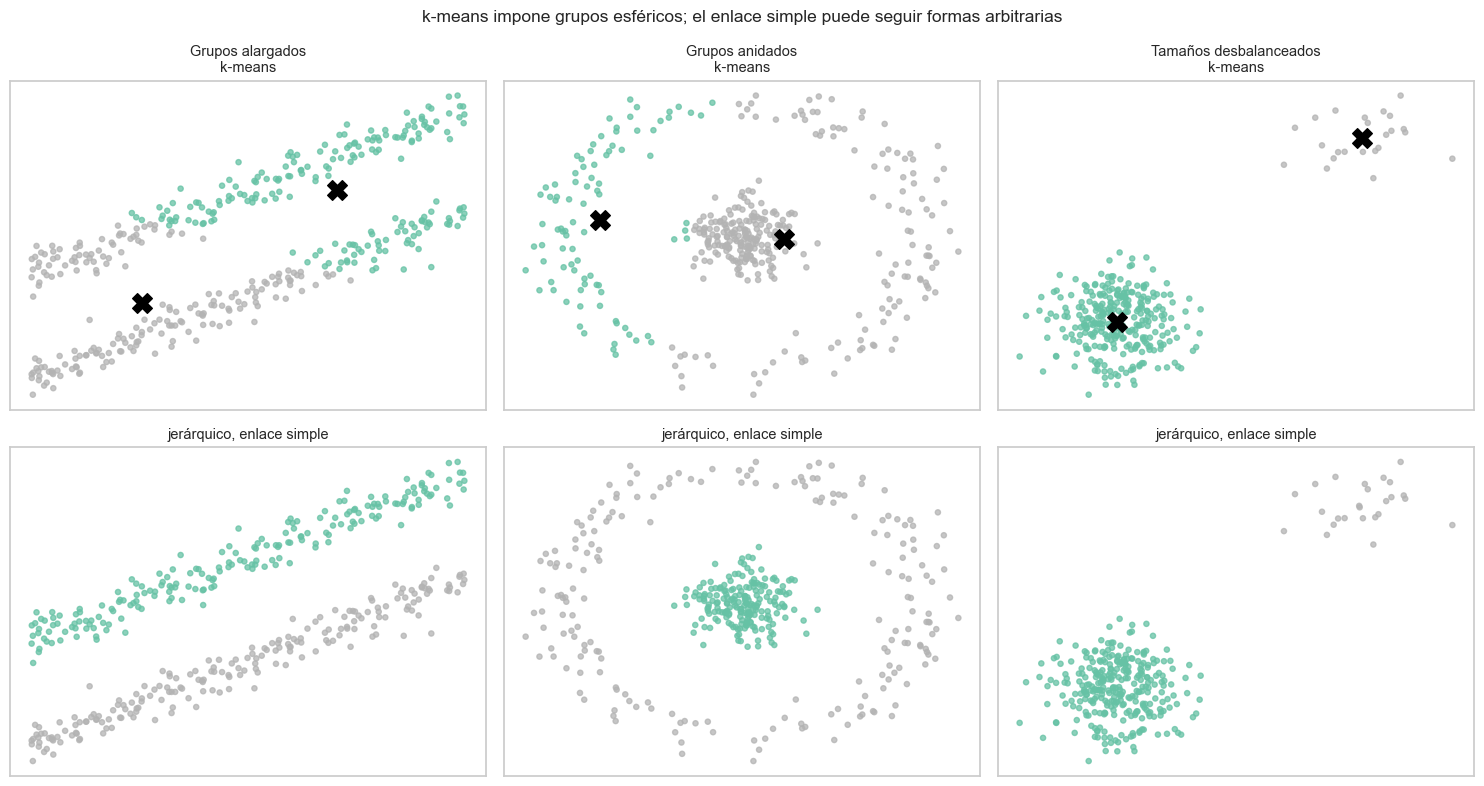

In [17]:
# Tres casos donde k-means falla, y qué hace el jerárquico
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 1) grupos alargados
t = rng.uniform(0, 1, 200)
X1 = np.vstack([np.c_[t * 8, t * 8 + rng.normal(0, 0.55, 200)],
                np.c_[t * 8, t * 8 + 5 + rng.normal(0, 0.55, 200)]])
# 2) grupos anidados
ang = rng.uniform(0, 2 * np.pi, 200)
X2 = np.vstack([rng.normal(0, 0.7, (200, 2)),
                np.c_[5 * np.cos(ang), 5 * np.sin(ang)] + rng.normal(0, 0.5, (200, 2))])
# 3) tamaños muy distintos
X3 = np.vstack([rng.normal([0, 0], 0.6, (300, 2)),
                rng.normal([4.5, 4.5], 0.6, (25, 2))])

for col, (Xc, titulo) in enumerate([(X1, "Grupos alargados"),
                                    (X2, "Grupos anidados"),
                                    (X3, "Tamaños desbalanceados")]):
    km = KMeans(n_clusters=2, n_init=25, random_state=SEED).fit(Xc)
    axes[0, col].scatter(Xc[:, 0], Xc[:, 1], c=km.labels_, cmap="Set2", s=14, alpha=0.75)
    axes[0, col].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                         marker="X", s=200, color="black")
    axes[0, col].set_title(f"{titulo}\nk-means", fontsize=10.5)

    lab = fcluster(linkage(Xc, method="single"), 2, criterion="maxclust")
    axes[1, col].scatter(Xc[:, 0], Xc[:, 1], c=lab, cmap="Set2", s=14, alpha=0.75)
    axes[1, col].set_title("jerárquico, enlace simple", fontsize=10.5)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("k-means impone grupos esféricos; el enlace simple puede seguir formas arbitrarias",
             fontsize=12.5)
plt.tight_layout()
plt.show()

Los tres casos son sintéticos y exagerados a propósito. Y notar la ironía: el enlace **simple**,
que descartamos por encadenar, es justamente el que resuelve bien los grupos alargados y
anidados. **No hay un método mejor en abstracto**; hay métodos que coinciden mejor o peor con la
forma que tienen los grupos reales, y esa forma no se conoce de antemano.

Para nuestro problema —una tipología ordenada de regímenes, con grupos que se esperan compactos—
Ward y k-means son adecuados.

### ¿Coinciden los dos métodos?

La prueba de estabilidad más simple: si dos algoritmos con lógicas distintas encuentran la misma
estructura, la estructura probablemente esté en los datos y no en el método.

In [18]:
etiquetas_jer = fcluster(Z, 3, criterion="maxclust")
kmeans_final = KMeans(n_clusters=3, n_init=25, random_state=SEED).fit(X)
etiquetas_km = kmeans_final.labels_

print(f"ARI entre jerárquico (Ward) y k-means: "
      f"{adjusted_rand_score(etiquetas_jer, etiquetas_km):.3f}")
print(f"\nARI de cada uno contra Freedom House:")
print(f"  jerárquico: {adjusted_rand_score(datos['fh_status'], etiquetas_jer):.3f}")
print(f"  k-means   : {adjusted_rand_score(datos['fh_status'], etiquetas_km):.3f}")
print()
print(pd.crosstab(etiquetas_jer, etiquetas_km,
                  rownames=["jerárquico"], colnames=["k-means"]))

ARI entre jerárquico (Ward) y k-means: 0.897

ARI de cada uno contra Freedom House:
  jerárquico: 0.613
  k-means   : 0.611

k-means      0   1   2
jerárquico            
1           61   0   0
2            0  43   0
3            2   4  60


Los dos métodos coinciden casi por completo —**ARI de 0.90**— y los dos alcanzan el mismo ARI
contra Freedom House (0.61 y 0.61). **La tripartición no es un artefacto del algoritmo.** Eso es
evidencia de estabilidad, y es la clase de chequeo que reemplaza a la validación cruzada cuando
no hay etiqueta.

Pero el ARI no es 1.0, y los pocos casos donde los métodos **discrepan** son informativos: son
los países que no encajan bien en ninguna categoría. Vale identificarlos ahora, porque uno de
ellos va a ser el protagonista del cierre.

In [19]:
siluetas_ind = silhouette_samples(X, etiquetas_jer)

# Los códigos de grupo son arbitrarios en los dos métodos. Para poder compararlos,
# los renombramos en los dos según el nivel medio de democracia liberal del grupo.
NIVELES = ["Autocracias", "Regímenes híbridos", "Democracias plenas"]

def nombrar(etiquetas):
    medias = pd.Series(datos["vdem_libdem"].values).groupby(etiquetas).mean().sort_values()
    mapa = {codigo: NIVELES[i] for i, codigo in enumerate(medias.index)}
    return [mapa[c] for c in etiquetas], mapa

nombres_jer, MAPA_JER = nombrar(etiquetas_jer)
nombres_km, _ = nombrar(kmeans_final.labels_)

comparar = pd.DataFrame({
    "país": datos["cname"].str.replace(r"\s*\(.*\)", "", regex=True),
    "jerárquico": nombres_jer,
    "k-means": nombres_km,
    "silueta": siluetas_ind.round(3),
})
discrepantes = comparar[comparar["jerárquico"] != comparar["k-means"]].sort_values("silueta")

print(f"Países clasificados distinto por los dos métodos: {len(discrepantes)} de {len(datos)}")
print(f"Países con silueta negativa (más cerca de otro grupo que del propio): "
      f"{int((siluetas_ind < 0).sum())}\n")
discrepantes.reset_index(drop=True)

Países clasificados distinto por los dos métodos: 6 de 170
Países con silueta negativa (más cerca de otro grupo que del propio): 7



,país,jerárquico,k-means,silueta
0,Argentina,Regímenes híbridos,Democracias plenas,-0.448
1,Moldova,Regímenes híbridos,Democracias plenas,-0.248
2,Bulgaria,Regímenes híbridos,Democracias plenas,-0.217
3,Mozambique,Regímenes híbridos,Autocracias,-0.102
4,South Africa,Regímenes híbridos,Democracias plenas,-0.090
5,Lebanon,Regímenes híbridos,Autocracias,-0.060


Solo **6 de 170 países** reciben clasificaciones distintas según el método, y **7** tienen silueta
negativa. Son los casos de frontera, y la lista es corta y sustantivamente coherente: países con
instituciones formales fuertes y desempeños desparejos.

Seguimos con la partición jerárquica, que es la que tiene el dendrograma asociado.

## Perfilar los grupos: ¿qué son?

El algoritmo devuelve números —grupo 1, 2, 3— sin nombres. Ponerles nombre es trabajo del
investigador, y se hace mirando las medias por grupo.

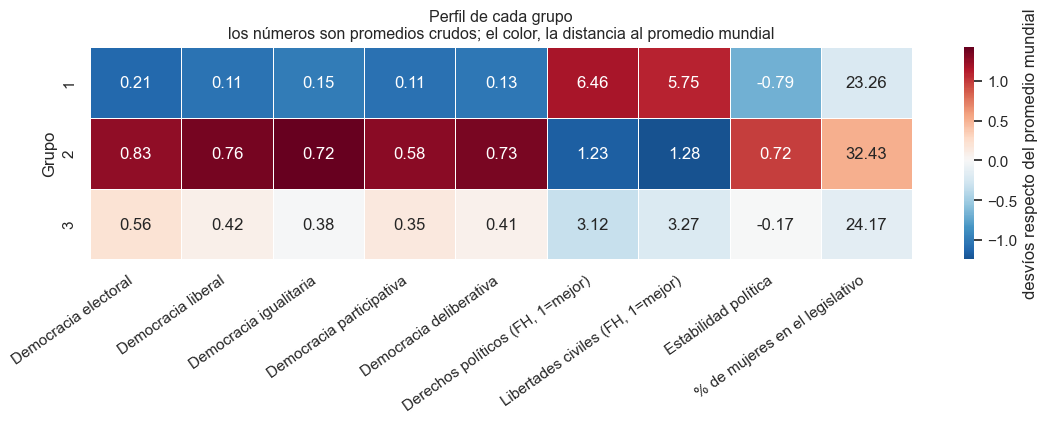

,vdem_polyarchy,vdem_libdem,vdem_egaldem,vdem_partipdem,vdem_delibdem,fh_pr,fh_cl,wbgi_pve,ipu_l_sw
cluster,,,,,,,,,
1,0.213,0.112,0.146,0.114,0.133,6.459,5.754,-0.785,23.262
2,0.835,0.755,0.718,0.580,0.731,1.233,1.279,0.719,32.435
3,0.559,0.416,0.377,0.354,0.409,3.121,3.273,-0.171,24.173


In [20]:
datos["cluster"] = etiquetas_jer

perfil = datos.groupby("cluster")[VARIABLES].mean()
perfil_z = (perfil - datos[VARIABLES].mean()) / datos[VARIABLES].std()

fig, ax = plt.subplots(figsize=(11.5, 4.4))
sns.heatmap(perfil_z.rename(columns=ETIQUETAS), annot=perfil.values, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.7,
            cbar_kws={"label": "desvíos respecto del promedio mundial"}, ax=ax)
ax.set_title("Perfil de cada grupo\nlos números son promedios crudos; el color, "
             "la distancia al promedio mundial", fontsize=11.5)
ax.set_ylabel("Grupo")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

perfil.round(3)

In [21]:
tamaño = datos["cluster"].value_counts().sort_index()
print("Tamaño de cada grupo:")
for c, n in tamaño.items():
    print(f"  grupo {c}: {n} países")

# Nombrar los grupos según su nivel de democracia liberal
orden = perfil["vdem_libdem"].sort_values()
NOMBRES = {orden.index[0]: "Autocracias",
           orden.index[1]: "Regímenes híbridos",
           orden.index[2]: "Democracias plenas"}
datos["tipo_regimen"] = datos["cluster"].map(NOMBRES)
print("\nNombres asignados según el nivel de democracia liberal:")
for c, nombre in sorted(NOMBRES.items()):
    print(f"  grupo {c} -> {nombre}  (n = {tamaño[c]})")

Tamaño de cada grupo:
  grupo 1: 61 países
  grupo 2: 43 países
  grupo 3: 66 países

Nombres asignados según el nivel de democracia liberal:
  grupo 1 -> Autocracias  (n = 61)
  grupo 2 -> Democracias plenas  (n = 43)
  grupo 3 -> Regímenes híbridos  (n = 66)


C:\Users\mmill\AppData\Local\Temp\ipykernel_12828\1072981315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x="cluster", y=var, order=orden_grupos, ax=ax,
C:\Users\mmill\AppData\Local\Temp\ipykernel_12828\1072981315.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([NOMBRES[c].split()[0] for c in orden_grupos], fontsize=8)
C:\Users\mmill\AppData\Local\Temp\ipykernel_12828\1072981315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x="cluster", y=var, order=orden_grupos, ax=ax,
C:\Users\mmill\AppData\Local\Temp\ipykernel_12828\1072981315.py:12: UserWarnin

C:\Users\mmill\AppData\Local\Temp\ipykernel_12828\1072981315.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([NOMBRES[c].split()[0] for c in orden_grupos], fontsize=8)
C:\Users\mmill\AppData\Local\Temp\ipykernel_12828\1072981315.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=datos, x="cluster", y=var, order=orden_grupos, ax=ax,
C:\Users\mmill\AppData\Local\Temp\ipykernel_12828\1072981315.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([NOMBRES[c].split()[0] for c in orden_grupos], fontsize=8)
C:\Users\mmill\AppData\Local\Temp\ipykernel_12828\1072981315.py:6: FutureWarning: 

Passing `palette` without assigning `hue`

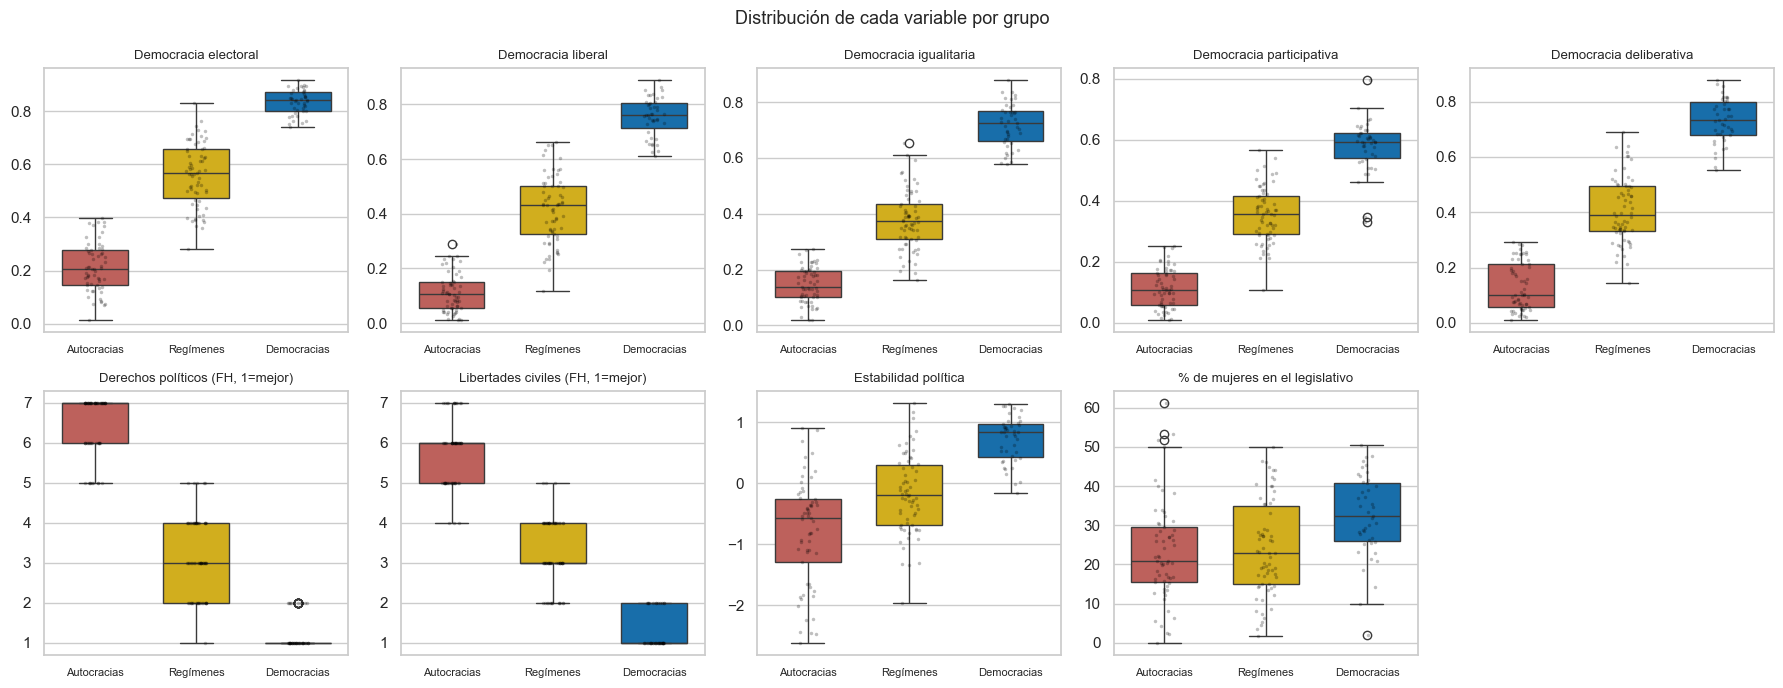

In [22]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
orden_grupos = [orden.index[0], orden.index[1], orden.index[2]]
paleta_g = {orden.index[0]: PALETA[2], orden.index[1]: PALETA[1], orden.index[2]: PALETA[0]}

for ax, var in zip(axes.ravel(), VARIABLES):
    sns.boxplot(data=datos, x="cluster", y=var, order=orden_grupos, ax=ax,
                palette=[paleta_g[c] for c in orden_grupos], width=0.65)
    sns.stripplot(data=datos, x="cluster", y=var, order=orden_grupos, ax=ax,
                  color="black", alpha=0.25, size=2.5)
    ax.set_title(ETIQUETAS[var], fontsize=9.5)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticklabels([NOMBRES[c].split()[0] for c in orden_grupos], fontsize=8)

axes.ravel()[-1].axis("off")
fig.suptitle("Distribución de cada variable por grupo", fontsize=13)
plt.tight_layout()
plt.show()

El patrón es un **gradiente ordenado** en las ocho primeras variables: los tres grupos se
alinean de menos a más democracia sin superposición fuerte. Eso confirma que la estructura
principal de estos datos es unidimensional —hay un eje de "cuánta democracia"— y que los grupos
son tramos de ese eje.

La excepción es el **porcentaje de mujeres en el legislativo**, donde las cajas se superponen
mucho más: hay autocracias con cuotas altas y democracias con representación baja. Es la única
de las nueve variables que no se ordena con el eje principal, y por eso aporta información
propia.

### El biplot de componentes principales

Nueve variables no se pueden graficar. El **análisis de componentes principales** construye
combinaciones lineales de las originales ordenadas por varianza explicada: PC1 es la dirección
de máxima dispersión, PC2 la siguiente entre las perpendiculares a PC1.

Un detalle técnico que casi nunca se explica: **el signo de un componente es arbitrario**. PC1 y
$-$PC1 explican lo mismo, y qué signo devuelve la librería depende de detalles numéricos. Para
que el gráfico sea interpretable conviene fijarlo: se busca la variable de mayor peso en cada
componente y, si carga negativo, se invierte el componente entero. Después cada eje crece en el
sentido de su variable dominante y se lo puede rotular con ella.

In [23]:
pca = PCA(n_components=4).fit(X)
componentes = pca.components_.copy()
puntajes = pca.transform(X)

# fijar el signo de cada componente según su variable dominante
for j in range(2):
    dominante = np.argmax(np.abs(componentes[j]))
    if componentes[j, dominante] < 0:
        componentes[j] *= -1
        puntajes[:, j] *= -1

var_exp = pca.explained_variance_ratio_ * 100
print("Varianza explicada por componente:")
for j, v in enumerate(var_exp, 1):
    print(f"  PC{j}: {v:5.1f}%")
print(f"\nPC1 + PC2 = {var_exp[:2].sum():.1f}% de la varianza total")

cargas = pd.DataFrame(componentes[:2].T, index=VARIABLES, columns=["PC1", "PC2"])
cargas.round(3)

Varianza explicada por componente:
  PC1:  80.2%
  PC2:   9.9%
  PC3:   6.3%
  PC4:   1.6%

PC1 + PC2 = 90.1% de la varianza total


,PC1,PC2
vdem_polyarchy,0.365,-0.067
vdem_libdem,0.367,-0.056
vdem_egaldem,0.363,0.003
vdem_partipdem,0.362,-0.011
vdem_delibdem,0.362,-0.033
fh_pr,-0.355,0.094
fh_cl,-0.356,0.111
wbgi_pve,0.260,0.002
ipu_l_sw,0.135,0.985


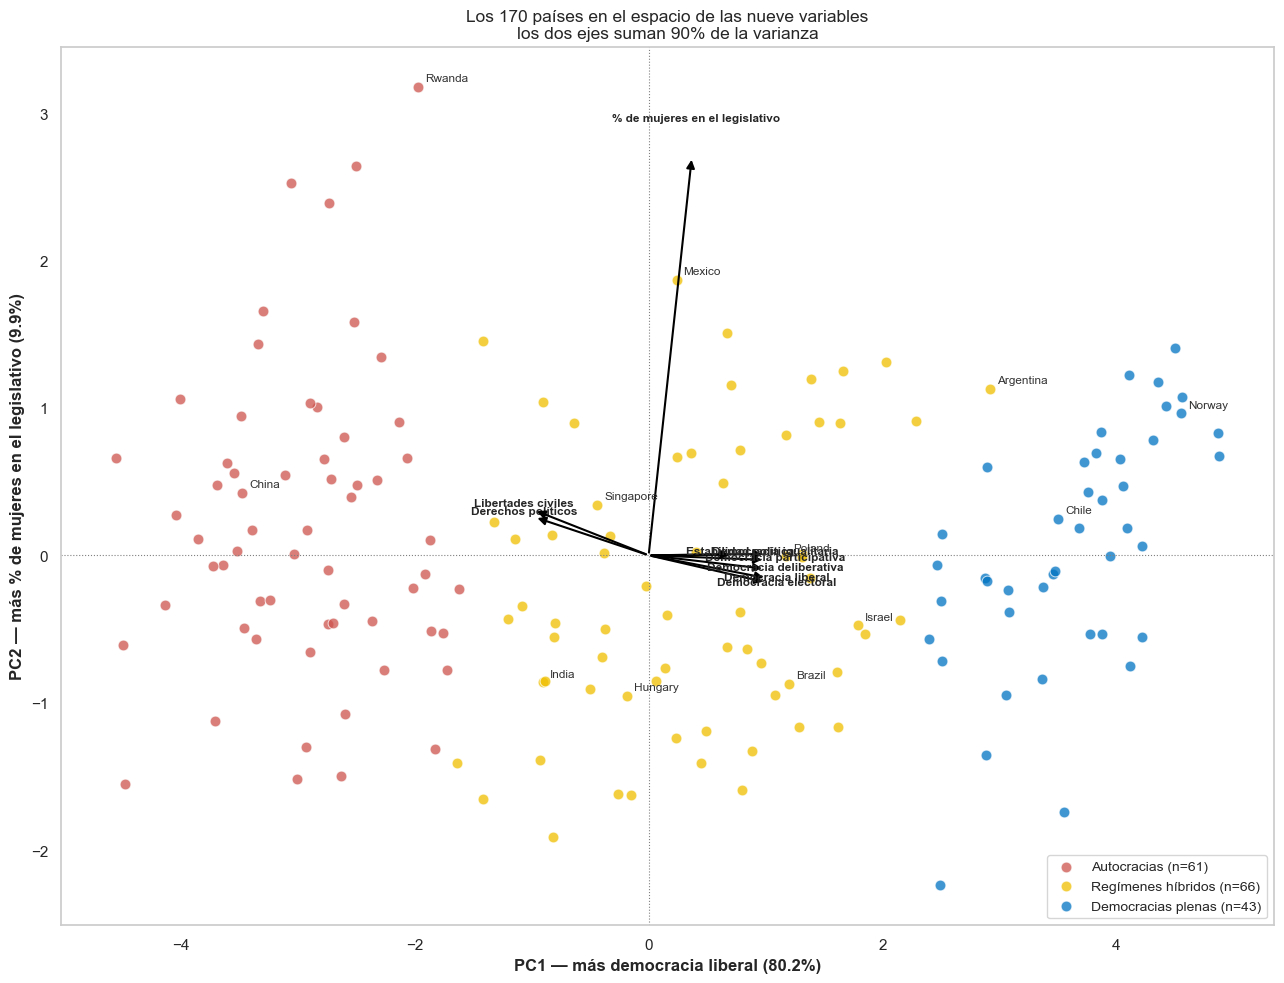

In [24]:
var_pc1 = VARIABLES[int(np.argmax(np.abs(componentes[0])))]
var_pc2 = VARIABLES[int(np.argmax(np.abs(componentes[1])))]

fig, ax = plt.subplots(figsize=(13, 10))

for c in orden_grupos:
    m = datos["cluster"] == c
    ax.scatter(puntajes[m, 0], puntajes[m, 1], s=60, alpha=0.75,
               color=paleta_g[c], edgecolor="white", linewidth=0.7,
               label=f"{NOMBRES[c]} (n={m.sum()})")

# flechas de las variables, escaladas al tamaño de la nube
escala = 0.85 * min(np.abs(puntajes[:, 0]).max() / np.abs(componentes[0]).max(),
                    np.abs(puntajes[:, 1]).max() / np.abs(componentes[1]).max())
for j, var in enumerate(VARIABLES):
    fx, fy = componentes[0, j] * escala, componentes[1, j] * escala
    ax.annotate("", xy=(fx, fy), xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color="black", lw=1.5))
    ax.text(fx * 1.09, fy * 1.09, ETIQUETAS[var].split("(")[0].strip(),
            fontsize=8.5, fontweight="bold", ha="center")

# etiquetar algunos países de referencia
REFERENCIA = ["Argentina", "Brazil", "Chile", "Norway", "China", "Hungary",
              "India", "Mexico", "Singapore", "Rwanda", "Poland", "Israel"]
for _, fila in datos[datos["cname"].isin(REFERENCIA)].iterrows():
    i = fila.name
    ax.annotate(fila["cname"][:14], (puntajes[i, 0], puntajes[i, 1]),
                fontsize=8.5, xytext=(5, 4), textcoords="offset points", color="#333")

ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.axvline(0, color="gray", ls=":", lw=0.8)
ax.set_xlabel(f"PC1 — más {ETIQUETAS[var_pc1].lower()} ({var_exp[0]:.1f}%)", fontweight="bold")
ax.set_ylabel(f"PC2 — más {ETIQUETAS[var_pc2].lower()} ({var_exp[1]:.1f}%)", fontweight="bold")
ax.set_title("Los 170 países en el espacio de las nueve variables\n"
             f"los dos ejes suman {var_exp[:2].sum():.0f}% de la varianza", fontsize=12.5)
ax.legend(fontsize=10, loc="lower right")
ax.grid(False)
plt.tight_layout()
plt.show()

El biplot condensa casi todo lo que hay que saber sobre estos datos.

**PC1 explica el 80% de la varianza por sí solo.** Eso confirma lo que insinuaban los boxplots:
las nueve variables miden fundamentalmente **una** cosa, y los grupos son tramos de ese eje. Las
flechas de las ocho variables de democracia apuntan casi todas en la misma dirección
horizontal, lo que es la representación gráfica de que están fuertemente correlacionadas — el
mismo fenómeno que en `9.1` nos obligaba a regularizar.

**PC2 explica solo el 10%** y su flecha dominante es el porcentaje de mujeres en el
legislativo, casi perpendicular a las demás. Perpendicular significa **no correlacionada**: la
representación femenina varía de forma independiente del nivel de democracia. Es el único aporte
de información realmente nuevo entre las nueve variables.

Los tres grupos aparecen como bandas verticales, ordenadas y con bordes difusos. Y ahí está el
punto que importa para el cierre: **Argentina cae en la frontera entre los híbridos y las
democracias plenas.**

## Validación externa

Sin etiqueta no hay validación cruzada. Pero hay algo casi igual de bueno: comparar la partición
contra una clasificación construida **independientemente y por otro método**.

Usamos dos: la clasificación de Freedom House —que asigna cada país a *Libre*, *Parcialmente
libre* o *No libre* mediante un panel de expertos— y la región geográfica.

El **índice de Rand ajustado (ARI)** mide la coincidencia entre dos particiones: vale 1 si son
idénticas y 0 si la coincidencia es la esperable por azar. Puede ser negativo.

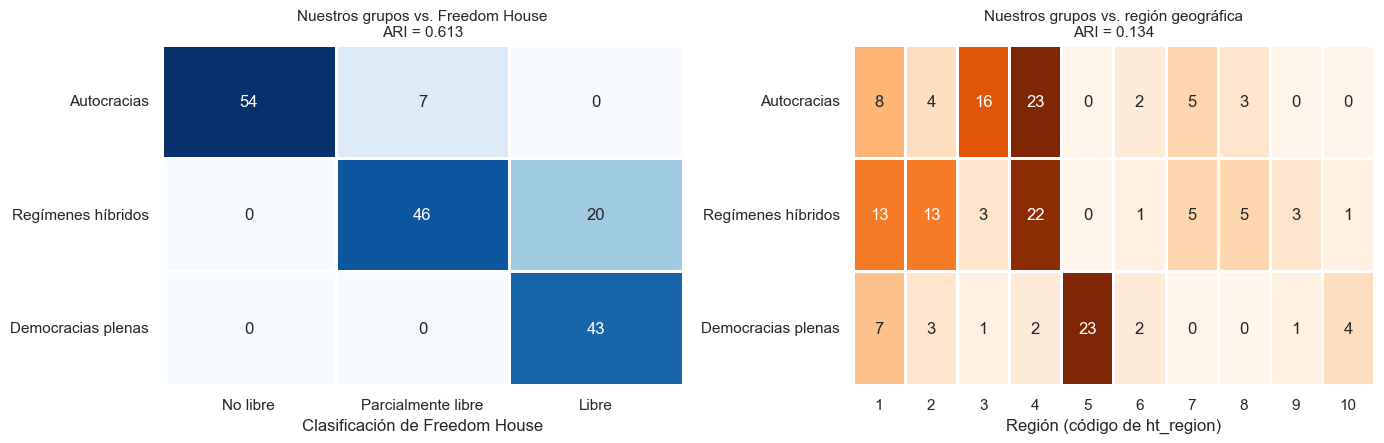

In [25]:
MAPA_FH = {1.0: "Libre", 2.0: "Parcialmente libre", 3.0: "No libre"}
datos["freedom_house"] = datos["fh_status"].map(MAPA_FH)

tabla_fh = pd.crosstab(datos["tipo_regimen"], datos["freedom_house"])
tabla_fh = tabla_fh.reindex(index=["Autocracias", "Regímenes híbridos", "Democracias plenas"],
                            columns=["No libre", "Parcialmente libre", "Libre"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
sns.heatmap(tabla_fh, annot=True, fmt="d", cmap="Blues", linewidths=0.8,
            cbar=False, ax=axes[0])
axes[0].set_title(f"Nuestros grupos vs. Freedom House\n"
                  f"ARI = {adjusted_rand_score(datos['fh_status'], etiquetas_jer):.3f}",
                  fontsize=11)
axes[0].set_xlabel("Clasificación de Freedom House"); axes[0].set_ylabel("")

tabla_reg = pd.crosstab(datos["tipo_regimen"], datos["ht_region"])
tabla_reg = tabla_reg.reindex(index=["Autocracias", "Regímenes híbridos", "Democracias plenas"])
sns.heatmap(tabla_reg, annot=True, fmt="d", cmap="Oranges", linewidths=0.8,
            cbar=False, ax=axes[1])
axes[1].set_title(f"Nuestros grupos vs. región geográfica\n"
                  f"ARI = {adjusted_rand_score(datos['ht_region'], etiquetas_jer):.3f}",
                  fontsize=11)
axes[1].set_xlabel("Región (código de ht_region)"); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

Los dos resultados dicen cosas distintas y las dos importan.

**Contra Freedom House, ARI = 0.61.** Es una coincidencia alta: la matriz es casi diagonal —las
43 democracias plenas del clustering son todas *Libres* para Freedom House, y las autocracias son
casi todas *No libres*—. Y llegamos ahí **sin usar la clasificación de Freedom House en ningún
momento**: emergió de nueve indicadores continuos.

Que no sea 1.0 tampoco es un fracaso: la discrepancia está concentrada en el grupo híbrido, que
mezcla países *Libres* y *Parcialmente libres*. O sea que nuestro corte y el de Freedom House
ubican la frontera de la democracia en lugares algo distintos, lo cual es exactamente el debate
sustantivo de la literatura sobre regímenes híbridos.

**Contra la región, ARI = 0.13.** Casi nada. Los tipos de régimen **no** siguen la geografía:
cada región contiene países de los tres grupos. Es un resultado sustantivo con consecuencias
metodológicas directas: **agrupar países por región, como se hace habitualmente, no los agrupa
por tipo de régimen.** Y de ahí sale el cierre de este notebook.

### MANOVA: ¿difieren los grupos?

El análisis multivariado de la varianza testea si los vectores de medias de los grupos son
iguales. Es la extensión multivariada del ANOVA.

In [26]:
datos_manova = datos[VARIABLES + ["cluster"]].copy()
datos_manova.columns = [c.replace("_", "") for c in datos_manova.columns]
formula = " + ".join([v.replace("_", "") for v in VARIABLES]) + " ~ C(cluster)"

manova = MANOVA.from_formula(formula, data=datos_manova)
resultado = manova.mv_test()
print(resultado.results["C(cluster)"]["stat"].round(4).to_string())

                            Value Num DF      Den DF     F Value Pr > F
Wilks' lambda            0.051421     18       318.0   60.241618    0.0
Pillai's trace           1.338101   18.0       320.0   35.939712    0.0
Hotelling-Lawley trace  10.872112     18  261.247899   95.560549    0.0
Roy's greatest root     10.123867      9         160  179.979865    0.0


El lambda de Wilks es 0.051 con $p < 0.001$: los grupos difieren de forma masiva.

> **Y ese resultado no significa casi nada.** Los grupos se construyeron **maximizando** la
> separación entre ellos usando **estas mismas variables**. Testear después si difieren es
> circular: la respuesta está garantizada por construcción. Un p-valor alto acá sería señal de
> que el algoritmo falló, no de que los grupos son iguales.
>
> Lo incluimos porque aparece con frecuencia en trabajos aplicados y conviene saber
> interpretarlo: **como descripción de cuánto separan los grupos, sirve; como test de hipótesis,
> no.** Para un test legítimo habría que evaluar la diferencia sobre variables que **no** se
> usaron para clusterizar — que es precisamente lo que hicimos con Freedom House.

## Ir más profundo: subclusterizar

El dendrograma mostraba subestructura dentro de cada rama. Con $k=3$ la desaprovechamos. Una
forma de recuperarla sin romper la tipología principal es **volver a clusterizar dentro de un
grupo**.

Lo aplicamos al grupo más grande, las autocracias, donde la literatura postula una distinción
importante: entre **autocracias cerradas** —sin elecciones multipartidarias— y **autocracias
electorales** o competitivas, que celebran elecciones pero sin condiciones de competencia justa.
Si esa distinción está en los datos, debería aparecer.

In [27]:
grupo_autocracias = orden.index[0]
sub = datos[datos["cluster"] == grupo_autocracias].reset_index(drop=True)
X_sub = StandardScaler().fit_transform(sub[VARIABLES])
Z_sub = linkage(X_sub, method="ward")

print(f"subclusterizando {len(sub)} autocracias\n")
for k in range(2, 5):
    lab = fcluster(Z_sub, k, criterion="maxclust")
    print(f"  k={k}: silueta = {silhouette_score(X_sub, lab):.3f}   "
          f"tamaños = {np.bincount(lab)[1:]}")

sub["subgrupo"] = fcluster(Z_sub, 2, criterion="maxclust")

subclusterizando 61 autocracias

  k=2: silueta = 0.313   tamaños = [27 34]
  k=3: silueta = 0.198   tamaños = [27 18 16]
  k=4: silueta = 0.168   tamaños = [ 6 21 18 16]


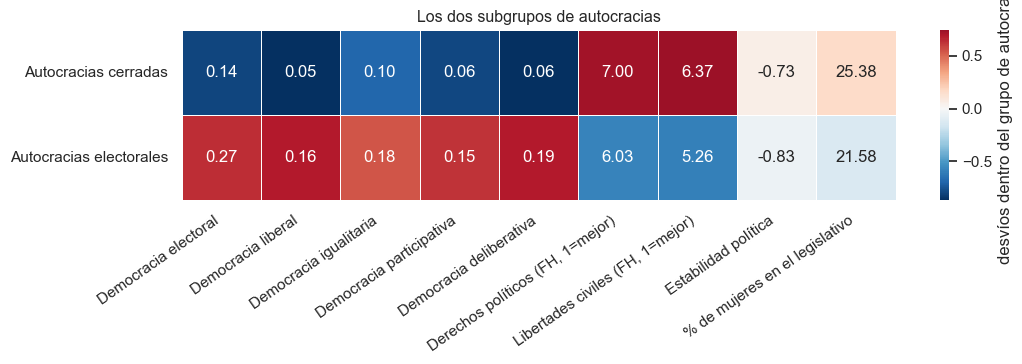


Autocracias cerradas (27):
  Afghanistan, Azerbaijan, Bahrain, Belarus, Burundi, Cambodia, Chad, China, Cuba, Equatorial Guinea, Eritrea, Eswatini, Iran, Korea, Lao People's Democratic Republic, Myanmar, Nicaragua, Russian Federation, Saudi Arabia, South Sudan, Syrian Arab Republic, Tajikistan, Turkmenistan, United Arab Emirates, Uzbekistan, Venezuela, Yemen

Autocracias electorales (34):
  Algeria, Angola, Bangladesh, Burkina Faso, Cameroon, Central African Republic, Comoros, Congo, Congo, Djibouti, Egypt, Ethiopia, Gabon, Guinea, Guinea-Bissau, Haiti, Iraq, Jordan, Kazakhstan, Kuwait, Kyrgyzstan, Libya, Mali, Mauritania, Morocco, Oman, Pakistan, Qatar, Rwanda, Thailand, Turkey, Uganda, Viet Nam, Zimbabwe


In [28]:
perfil_sub = sub.groupby("subgrupo")[VARIABLES].mean()
media_sub = perfil_sub["vdem_polyarchy"].sort_values()
NOMBRES_SUB = {media_sub.index[0]: "Autocracias cerradas",
               media_sub.index[1]: "Autocracias electorales"}
sub["tipo_autocracia"] = sub["subgrupo"].map(NOMBRES_SUB)

fig, ax = plt.subplots(figsize=(11, 3.8))
p_sub_z = ((perfil_sub - sub[VARIABLES].mean()) / sub[VARIABLES].std())
p_sub_z.index = [NOMBRES_SUB[i] for i in p_sub_z.index]
sns.heatmap(p_sub_z.rename(columns=ETIQUETAS), annot=perfil_sub.values, fmt=".2f",
            cmap="RdBu_r", center=0, linewidths=0.7, ax=ax,
            cbar_kws={"label": "desvíos dentro del grupo de autocracias"})
ax.set_title("Los dos subgrupos de autocracias", fontsize=11.5)
ax.set_ylabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

for nombre in ["Autocracias cerradas", "Autocracias electorales"]:
    paises = sorted(sub.loc[sub["tipo_autocracia"] == nombre, "cname"]
                    .str.replace(r"\s*\(.*\)", "", regex=True))
    print(f"\n{nombre} ({len(paises)}):")
    print("  " + ", ".join(paises))

La subclusterización recupera **exactamente la distinción teórica**. El subgrupo con menor
democracia electoral reúne a China, Cuba, Irán, Corea del Norte, Bielorrusia, Eritrea, Arabia
Saudita: los casos donde no hay competencia electoral en ningún sentido. El otro reúne a
Argelia, Angola, Bangladesh, Egipto, Etiopía, Camerún: regímenes que celebran elecciones sin
competencia real.

Que una distinción conceptual desarrollada teóricamente aparezca al subdividir un grupo formado
sin usarla es un argumento fuerte a favor de que la estructura es real. Y es la forma correcta
de usar el clustering en política comparada: **no para reemplazar la teoría sino para ponerla a
prueba.**

## Cierre aplicado: elegir casos comparables

Acá está la aplicación concreta, y es una de las decisiones más consecuentes en el diseño de una
investigación de política comparada: **¿contra qué países comparo el mío?**

La respuesta habitual es la región. Se estudia Argentina junto a Brasil, Chile, Uruguay y México
porque comparten idioma, historia colonial y vecindad. Es cómodo y a veces correcto, pero es una
decisión que casi nunca se justifica con datos.

El clustering permite justificarla —o refutarla—. Ya sabemos que el ARI entre nuestros grupos y
la región es 0.13, o sea que la región casi no informa sobre el tipo de régimen. Veamos qué
significa eso para el caso argentino.

In [29]:
i_arg = int(datos.index[datos["cname"] == "Argentina"][0])
cluster_arg = datos.loc[i_arg, "cluster"]

print(f"Argentina pertenece al grupo '{datos.loc[i_arg, 'tipo_regimen']}' "
      f"({(datos['cluster'] == cluster_arg).sum()} países)")
print(f"Freedom House la clasifica como: {datos.loc[i_arg, 'freedom_house']}")
sil_arg = siluetas_ind[i_arg]
print(f"\ncoeficiente de silueta: {sil_arg:+.3f}")
print(f"puesto en el ranking de ambigüedad: {int((siluetas_ind <= sil_arg).sum())} "
      f"de {len(datos)}   (1 = el caso que peor encaja en su grupo)")
print("\nUn valor NEGATIVO significa que está más cerca del centro de otro grupo "
      "que del propio.")
print(f"Clasificación según k-means: {nombres_km[i_arg]}")

Argentina pertenece al grupo 'Regímenes híbridos' (66 países)
Freedom House la clasifica como: Libre

coeficiente de silueta: -0.448
puesto en el ranking de ambigüedad: 1 de 170   (1 = el caso que peor encaja en su grupo)

Un valor NEGATIVO significa que está más cerca del centro de otro grupo que del propio.
Clasificación según k-means: Democracias plenas


In [30]:
# La región de Argentina, y cómo se reparte entre los grupos
region_arg = datos.loc[i_arg, "ht_region"]
misma_region = datos[datos["ht_region"] == region_arg]

print(f"Países de la misma región que Argentina (ht_region = {region_arg}): "
      f"{len(misma_region)}\n")
reparto = pd.crosstab(misma_region["tipo_regimen"], misma_region["freedom_house"],
                      margins=True, margins_name="Total")
print(reparto.to_string())
print(f"\nDe los {len(misma_region) - 1} vecinos regionales, "
      f"{int((misma_region['cluster'] == cluster_arg).sum()) - 1} comparten grupo con Argentina "
      f"y {int((misma_region['cluster'] != cluster_arg).sum())} no.")

Países de la misma región que Argentina (ht_region = 2): 20

freedom_house       Libre  No libre  Parcialmente libre  Total
tipo_regimen                                                  
Autocracias             0         4                   0      4
Democracias plenas      3         0                   0      3
Regímenes híbridos      5         0                   8     13
Total                   8         4                   8     20

De los 19 vecinos regionales, 12 comparten grupo con Argentina y 7 no.


In [31]:
# Los vecinos reales: distancia en el espacio de las nueve variables
matriz_dist = squareform(pdist(X, metric="euclidean"))
orden_cercania = np.argsort(matriz_dist[i_arg])[1:16]

vecinos = pd.DataFrame({
    "país": datos.loc[orden_cercania, "cname"].str.replace(r"\s*\(.*\)", "", regex=True).values,
    "distancia": matriz_dist[i_arg][orden_cercania].round(3),
    "grupo": datos.loc[orden_cercania, "tipo_regimen"].values,
    "Freedom House": datos.loc[orden_cercania, "freedom_house"].values,
    "misma región": np.where(
        datos.loc[orden_cercania, "ht_region"].values == region_arg, "sí", "no"),
}).reset_index(drop=True)
vecinos.index += 1
vecinos

,país,distancia,grupo,Freedom House,misma región
1,Moldova,0.933,Regímenes híbridos,Parcialmente libre,no
2,Spain,1.059,Democracias plenas,Libre,no
3,Austria,1.153,Democracias plenas,Libre,no
4,Slovenia,1.219,Democracias plenas,Libre,no
5,Chile,1.250,Democracias plenas,Libre,sí
6,United Kingdom of Great Britain and Northern I...,1.278,Democracias plenas,Libre,no
7,South Africa,1.280,Regímenes híbridos,Libre,no
8,France,1.285,Democracias plenas,Libre,no
9,Senegal,1.317,Regímenes híbridos,Parcialmente libre,no
10,Suriname,1.344,Democracias plenas,Libre,no


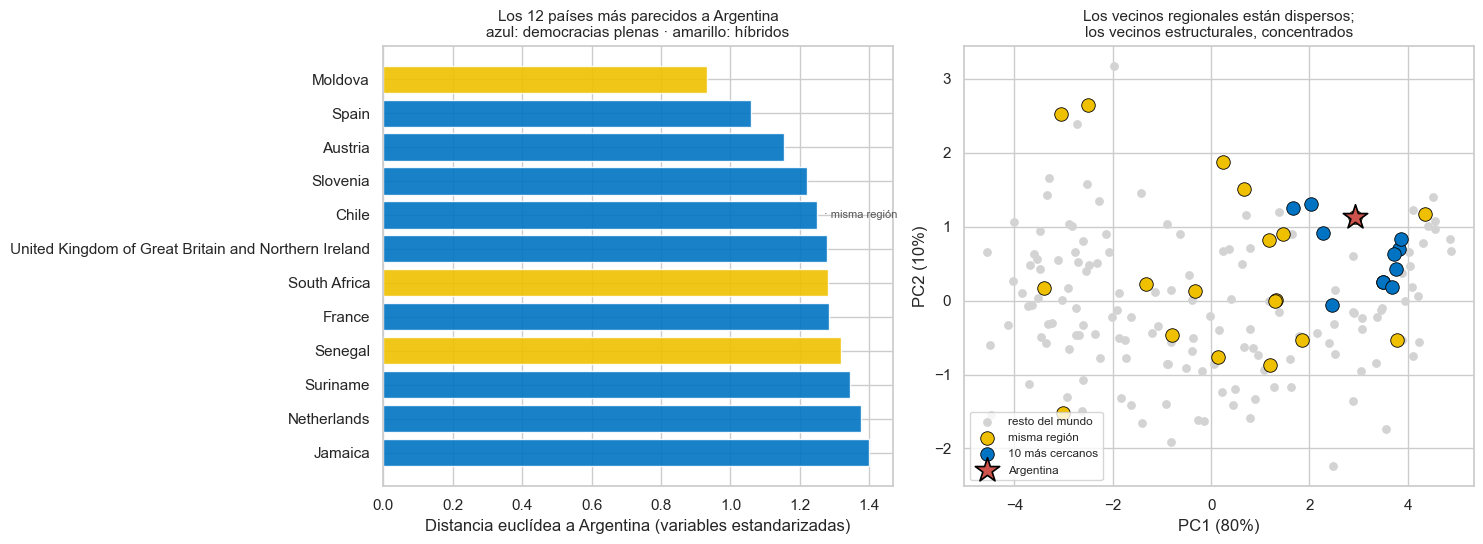

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.6))

# panel 1: los vecinos más cercanos
v = vecinos.head(12).iloc[::-1]
colores_v = [PALETA[0] if g == "Democracias plenas" else
             PALETA[1] if g == "Regímenes híbridos" else PALETA[2] for g in v["grupo"]]
axes[0].barh(v["país"], v["distancia"], color=colores_v, alpha=0.9)
for i, (d, r) in enumerate(zip(v["distancia"], v["misma región"])):
    axes[0].text(d + 0.02, i, "· misma región" if r == "sí" else "", va="center",
                 fontsize=8, color="#555")
axes[0].set_xlabel("Distancia euclídea a Argentina (variables estandarizadas)")
axes[0].set_title("Los 12 países más parecidos a Argentina\n"
                  "azul: democracias plenas · amarillo: híbridos", fontsize=11)

# panel 2: región vs vecindad real, en el plano de PC1-PC2
axes[1].scatter(puntajes[:, 0], puntajes[:, 1], s=28, color="lightgray",
                label="resto del mundo", zorder=1)
m_reg = (datos["ht_region"] == region_arg).values
axes[1].scatter(puntajes[m_reg, 0], puntajes[m_reg, 1], s=95, color=PALETA[1],
                edgecolor="black", linewidth=0.6, label="misma región", zorder=2)
m_cerca = np.zeros(len(datos), bool); m_cerca[orden_cercania[:10]] = True
axes[1].scatter(puntajes[m_cerca, 0], puntajes[m_cerca, 1], s=95, color=PALETA[0],
                edgecolor="black", linewidth=0.6, label="10 más cercanos", zorder=3)
axes[1].scatter(puntajes[i_arg, 0], puntajes[i_arg, 1], s=340, marker="*",
                color=PALETA[2], edgecolor="black", linewidth=1.2,
                label="Argentina", zorder=5)
axes[1].set_xlabel(f"PC1 ({var_exp[0]:.0f}%)")
axes[1].set_ylabel(f"PC2 ({var_exp[1]:.0f}%)")
axes[1].set_title("Los vecinos regionales están dispersos;\n"
                  "los vecinos estructurales, concentrados", fontsize=11)
axes[1].legend(fontsize=8.5, loc="lower left")

plt.tight_layout()
plt.show()

### Lo que dice el resultado

Tres hallazgos, en orden de importancia.

**1. Argentina es el caso más ambiguo de los 170.** Su coeficiente de silueta es **−0.448**, el
más negativo de toda la muestra. Un valor negativo significa algo concreto: **Argentina está más
cerca del centro de otro grupo que del centro del propio**. El clustering jerárquico la ubica
entre los regímenes híbridos, pero geométricamente pertenece a las democracias plenas.

Y eso se confirma por otra vía: **k-means, corriendo sobre los mismos datos, la clasifica como
democracia plena.** Argentina es uno de los seis países —de 170— sobre los que los dos métodos
discrepan, y encabeza esa lista. Freedom House, por su parte, la clasifica como *Libre*.

Sus vecinos más cercanos confirman el diagnóstico: Moldavia primero, y después **España, Austria,
Eslovenia, Chile, Reino Unido y Francia**, todas democracias plenas.

Esto es información que la etiqueta de cluster **oculta por completo**. Un análisis que reporte
"Argentina pertenece al grupo de regímenes híbridos" no está equivocado, pero omite lo más
relevante: que es el caso que peor encaja en esa categoría de toda la muestra. **Para los casos de
frontera, la distancia y la silueta importan más que la etiqueta**, y reportar solo la etiqueta es
una pérdida de información grave.

**2. La región no es un criterio de comparabilidad.** De los 19 vecinos regionales de Argentina,
12 comparten su grupo y 7 no: hay cuatro autocracias y tres democracias plenas en la misma
región. El panel derecho lo muestra gráficamente — los países de la región están **desparramados**
por todo el plano, mientras que los diez vecinos estructurales forman un grupo compacto alrededor
de Argentina.

Comparar Argentina con "América Latina" es comparar contra un conjunto heterogéneo en la
dimensión que importa.

**3. Los pares defendibles no son los obvios.** España, Austria y Eslovenia aparecen antes que
Brasil o México en la lista de países estructuralmente parecidos.

In [33]:
# El producto: tres diseños comparados, cada uno con su justificación
print("=" * 78)
print("SELECCIÓN DE CASOS PARA UN ESTUDIO SOBRE ARGENTINA")
print("=" * 78)

# A) casos más similares
similares = vecinos.head(5)
print("\nA) DISEÑO DE CASOS SIMILARES  (most similar systems)")
print("   Para aislar el efecto de una variable no incluida en el clustering:")
print("   se comparan países parecidos en todo lo demás.")
for _, f in similares.iterrows():
    print(f"     · {f['país']:<22s} d = {f['distancia']:.3f}   ({f['grupo']})")

# B) mismo grupo, extremos opuestos
grupo = datos[datos["cluster"] == cluster_arg].copy()
grupo["d_arg"] = matriz_dist[i_arg][grupo.index]
print("\nB) DISEÑO DE VARIACIÓN DENTRO DEL GRUPO")
print("   Los casos más distintos DENTRO del mismo tipo de régimen:")
for _, f in grupo.nlargest(4, "d_arg").iterrows():
    print(f"     · {f['cname'][:22]:<22s} d = {f['d_arg']:.3f}")

# C) vecinos regionales que NO comparten grupo
distintos = misma_region[misma_region["cluster"] != cluster_arg].copy()
distintos["d_arg"] = matriz_dist[i_arg][distintos.index]
print("\nC) DISEÑO REGIÓN vs. RÉGIMEN")
print("   Vecinos regionales que NO comparten tipo de régimen:")
print("   sirven para separar el efecto del contexto regional del efecto institucional.")
for _, f in distintos.nsmallest(5, "d_arg").iterrows():
    print(f"     · {f['cname'][:22]:<22s} d = {f['d_arg']:.3f}   ({f['tipo_regimen']})")
print("\n" + "=" * 78)

SELECCIÓN DE CASOS PARA UN ESTUDIO SOBRE ARGENTINA

A) DISEÑO DE CASOS SIMILARES  (most similar systems)
   Para aislar el efecto de una variable no incluida en el clustering:
   se comparan países parecidos en todo lo demás.
     · Moldova                d = 0.933   (Regímenes híbridos)
     · Spain                  d = 1.059   (Democracias plenas)
     · Austria                d = 1.153   (Democracias plenas)
     · Slovenia               d = 1.219   (Democracias plenas)
     · Chile                  d = 1.250   (Democracias plenas)

B) DISEÑO DE VARIACIÓN DENTRO DEL GRUPO
   Los casos más distintos DENTRO del mismo tipo de régimen:
     · Nigeria                d = 5.310
     · Lebanon                d = 5.243
     · Papua New Guinea       d = 4.865
     · Benin                  d = 4.679

C) DISEÑO REGIÓN vs. RÉGIMEN
   Vecinos regionales que NO comparten tipo de régimen:
   sirven para separar el efecto del contexto regional del efecto institucional.
     · Chile                  

### El producto

Lo que este notebook entrega no es una lista de clusters: es **una tabla de distancias que
convierte la selección de casos en una decisión justificable**.

Antes, la respuesta a "¿por qué comparás Argentina con Chile y Brasil?" era "porque son de la
región". Ahora se puede responder con precisión: *Chile está a 1.25 de distancia y es un caso
similar útil; Brasil está más lejos y pertenece al mismo grupo pero en otra zona; España está a
1.06 y es estructuralmente más parecida que cualquier vecino sudamericano excepto Chile.*

Y la pregunta que abre —**¿por qué Argentina tiene los indicadores institucionales de España y
Eslovenia pero se agrupa con los híbridos?**— es sustantiva. Se conecta directamente con el
hallazgo de `9.1`: Argentina puntúa 16 puntos por debajo de lo que su estructura predice en
percepción de corrupción. Los dos notebooks, con métodos completamente distintos, señalan el
mismo fenómeno: **Argentina tiene instituciones formales de democracia plena y desempeños que no
se corresponden.** Ninguno de los dos explica por qué. Los dos delimitan la pregunta.

## Síntesis

1. **Sin etiqueta no hay respuesta correcta.** El éxito de un clustering se juzga por
   interpretabilidad, estabilidad entre métodos y correspondencia con clasificaciones externas —
   no por una métrica de error.

2. **Antes de clusterizar hay que entender las variables.** `bmr_demdur` asigna 221 años de
   "duración de régimen" a China e Irán, y al incluirla el algoritmo formaba un grupo definido
   por ese artefacto.

3. **Estandarizar es obligatorio.** Sin escalar, el 95% de la varianza la aportaba una sola
   variable por su escala, y el agrupamiento se volvía una partición por esa variable.

4. Los **criterios de enlace** producen árboles radicalmente distintos. El coeficiente cofenético
   prefería `average`, y elegimos **Ward** por interpretabilidad y por coherencia con la forma en
   que después leemos los grupos. La decisión se justifica, no se esconde.

5. **Los criterios para elegir $k$ no coinciden**: la silueta dice 2, Calinski-Harabasz y la
   validación externa dicen 3. Elegimos 3 por la conjunción de evidencia métrica y teoría.

6. El **diagrama de silueta por cluster** muestra lo que el promedio esconde: qué grupos están
   bien definidos y qué casos están en la frontera.

7. **k-means y el jerárquico de Ward coinciden casi por completo** (ARI alto entre ellos), lo que
   es evidencia de que la estructura está en los datos y no en el método.

8. **La validación externa es la pieza clave**: ARI de 0.61 contra Freedom House sin haber usado
   esa clasificación, y de 0.13 contra la región. Los tipos de régimen no siguen la geografía.

9. La **MANOVA** sobre las variables usadas para clusterizar es circular y no constituye un test.
   La validación legítima usa variables externas.

10. La **subclusterización** de las autocracias recupera la distinción teórica entre autocracias
    cerradas y electorales, sin haberla usado para construir los grupos.

11. El cierre no es una tipología: es una **tabla de distancias que justifica la selección de
    casos**, con el hallazgo de que Argentina está en la frontera y que sus pares estructurales
    no son sus vecinos regionales.

## Lo que sigue

En `9.5` cerramos la unidad con el otro método no supervisado del programa: **reglas de
asociación**. Cambia la unidad de análisis —ya no agrupamos casos parecidos sino que buscamos
qué atributos aparecen juntos— y cambia el tipo de dato: en lugar de una matriz de variables
continuas, un conjunto de transacciones.